<a href="https://colab.research.google.com/github/GoudoMahan/AI-agent-practice/blob/main/HM_3_2_slam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 作业3-任务2：基于滤波方法的 SLAM
---

姓名：胡豪达

学号：523021910471

---

本 Task 占比本作业评分的 50%，分为两个部分：

| 部分 | 内容 | 分值 |
|------|------|------|
| Part 1 | 卡尔曼滤波 SLAM | 50 |
| Part 2 | 粒子滤波 SLAM | 50 |

**⚠️ 重要提示：**
- 选择 **CPU 运行时**（`运行时 → 更改运行时类型 → CPU`）
- <mark> 👉  高亮块是你需要完成或者修改的内容提示，你需要根据任务要求修改对应地方下方的代码块 </mark>，其余代码块请按顺序运行

---
## 🧾 Part 1 — <span style="color:#a4d4a3">**Extended Kalman Filter (EKF) for SLAM**</span>（50 分）

### 🎯 你的任务

- 完整运行整个代码，体会 EKF-SLAM 的核心思想：将机器人的瞬时位姿和所有已观测到的环境特征（landmark）融合为一个巨大的联合状态向量，假设该系统的真实状态及不确定性服从多元高斯分布，并基于扩展卡尔曼滤波的“预测-更新”框架，在一个统一的概率空间中同时估计机器人轨迹与地图的最佳后验期望。
- 调整以下几个核心参数，填写表格，感受状态估计系统是如何在不同信息源之间进行博弈的。

| 参数 | 物理意义 |
|------|------|
| 过程噪声协方差矩阵 $Q$ (Process Noise Covariance) | 代表你对机器人运动模型（里程计、IMU）的信任程度 |
| 观测噪声协方差矩阵 $R$ (Measurement Noise Covariance) | 代表你对外部传感器（激光雷达、相机、声纳）观测质量的信任程度 |


#### 1.1 状态空间定义

我们为一个在平面内运动的机器人定义状态空间，观测到 $N$ 个 landmark (特征点)，则状态空间定义为：

$$
x_t = (\underbrace{x, y, \theta}_{robot\,state}, \underbrace{m_{1,x}, m_{1,y}}_{landmark\,1}, \underbrace{m_{2,x}, m_{2,y}}_{landmark\,2}, \dots, \underbrace{m_{N,x}, m_{N,y}}_{landmark\,N})^T
$$

地图中有 $N$ 个路标，因此状态向量维度为 $3 + 2N$。我们定义这 $3 + 2N$ 个状态变量的的均值和方差为：

- <span style="color:#ffa500">**均值向量**</span> $ \mu $ and <span style="color:#ffa500">**方差矩阵**</span> $ \Sigma $:

$$
\mu =
\begin{pmatrix}
\color{#FFD93D} x \\
\color{#FFD93D} y \\
\color{#FFD93D} \theta \\
\color{#4D96FF} m_{1,x} \\
\color{#4D96FF} m_{1,y} \\
\color{#4D96FF} \vdots \\
\color{#4D96FF} m_{N,x} \\
\color{#4D96FF} m_{N,y}
\end{pmatrix}
$$

$$
\Sigma =
\left(
\begin{array}{ccc:ccccc}
\color{#FFD93D} \sigma_{x,x} & \color{#FFD93D} \sigma_{x,y} & \color{#FFD93D} \sigma_{x,\theta} & \color{#6BCB77} \sigma_{x,m_{1,x}} & \color{#6BCB77} \sigma_{x,m_{1,y}} & \color{#6BCB77} \cdots & \color{#6BCB77} \sigma_{x,m_{N,x}} & \color{#6BCB77} \sigma_{x,m_{N,y}} \\
\color{#FFD93D} \sigma_{y,x} & \color{#FFD93D} \sigma_{y,y} & \color{#FFD93D} \sigma_{y,\theta} & \color{#6BCB77} \sigma_{y,m_{1,x}} & \color{#6BCB77} \sigma_{y,m_{1,y}} & \color{#6BCB77} \cdots & \color{#6BCB77} \sigma_{y,m_{N,x}} & \color{#6BCB77} \sigma_{y,m_{N,y}} \\
\color{#FFD93D} \sigma_{\theta,x} & \color{#FFD93D} \sigma_{\theta,y} & \color{#FFD93D} \sigma_{\theta,\theta} & \color{#6BCB77} \sigma_{\theta,m_{1,x}} & \color{#6BCB77} \sigma_{\theta,m_{1,y}} & \color{#6BCB77} \cdots & \color{#6BCB77} \sigma_{\theta,m_{N,x}} & \color{#6BCB77} \sigma_{\theta,m_{N,y}} \\
\hdashline
\color{#6BCB77} \sigma_{m_{1,x},x} & \color{#6BCB77} \sigma_{m_{1,x},y} & \color{#6BCB77} \sigma_{m_{1,x},\theta} & \color{#4D96FF} \sigma_{m_{1,x},m_{1,x}} & \color{#4D96FF} \sigma_{m_{1,x},m_{1,y}} & \color{#4D96FF} \cdots & \color{#4D96FF} \sigma_{m_{1,x},m_{N,x}} & \color{#4D96FF} \sigma_{m_{1,x},m_{N,y}} \\
\color{#6BCB77} \sigma_{m_{1,y},x} & \color{#6BCB77} \sigma_{m_{1,y},y} & \color{#6BCB77} \sigma_{m_{1,y},\theta} & \color{#4D96FF} \sigma_{m_{1,y},m_{1,x}} & \color{#4D96FF} \sigma_{m_{1,y},m_{1,y}} & \color{#4D96FF} \cdots & \color{#4D96FF} \sigma_{m_{1,y},m_{N,x}} & \color{#4D96FF} \sigma_{m_{1,y},m_{N,y}} \\
\color{#6BCB77} \vdots & \color{#6BCB77} \vdots & \color{#6BCB77} \vdots & \color{#4D96FF} \vdots & \color{#4D96FF} \vdots & \color{#4D96FF} \ddots & \color{#4D96FF} \vdots & \color{#4D96FF} \vdots \\
\color{#6BCB77} \sigma_{m_{N,x},x} & \color{#6BCB77} \sigma_{m_{N,x},y} & \color{#6BCB77} \sigma_{m_{N,x},\theta} & \color{#4D96FF} \sigma_{m_{N,x},m_{1,x}} & \color{#4D96FF} \sigma_{m_{N,x},m_{1,y}} & \color{#4D96FF} \cdots & \color{#4D96FF} \sigma_{m_{N,x},m_{N,x}} & \color{#4D96FF} \sigma_{m_{N,x},m_{N,y}} \\
\color{#6BCB77} \sigma_{m_{N,y},x} & \color{#6BCB77} \sigma_{m_{N,y},y} & \color{#6BCB77} \sigma_{m_{N,y},\theta} & \color{#4D96FF} \sigma_{m_{N,y},m_{1,x}} & \color{#4D96FF} \sigma_{m_{N,y},m_{1,y}} & \color{#4D96FF} \cdots & \color{#4D96FF} \sigma_{m_{N,y},m_{N,x}} & \color{#4D96FF} \sigma_{m_{N,y},m_{N,y}} \\
\end{array}
\right)
$$


可以紧凑地记为:
$\quad \mu = \begin{pmatrix}\color{#FFD93D} x \\ \color{#4D96FF} m\end{pmatrix}\quad\quad\Sigma = \begin{pmatrix}\color{#FFD93D} \Sigma_{xx} & \color{#6BCB77} \Sigma_{xm}\\\color{#6BCB77} \Sigma_{mx} & \color{#4D96FF} \Sigma_{mm}\end{pmatrix}$

至此，我们完成了 EKF-SLAM 的第一步：将机器人的瞬时位姿和所有已观测到的环境特征（landmark）融合为一个巨大的联合状态向量，假设该系统的真实状态及不确定性服从多元高斯分布。


接着我们进入  EKF-SLAM 循环中核心的五个连续步骤，我可以形象地理解为在一个放满家具的黑暗房间里，靠着感知和记忆不断摸索前行的过程。


1. 状态预测 (State Prediction) —— “盲走与预判”：你蒙着眼睛向前走了一步。根据你对自己步伐大小和方向的了解，你猜自己现在大概走到了房间的哪个位置。但是同时因为你的步伐不可能百分之百精确，所以走完这一步后，你对自身位置的“确信度”下降了（在数学上表现为机器人位姿协方差矩阵的膨胀）。

2. 观测预测 (Observation Prediction) —— “脑补画面”：在睁开眼睛之前，你调动大脑里的记忆（上一时刻保存的地图）。你心想：“既然我刚刚往前走了一大步，如果我的预判是对的，那么现在我的右前方面前大概 1 米处，应该会出现那张我之前见过的沙发。” 根据预测的当前位置和地图中已有路标的位置，计算出传感器理论上应该输出的读数（预期距离和角度）。

3. 观测测量 (Measurement) —— “睁眼看世界”：你睁开眼睛（或者打开激光雷达/相机），实际测量了一下周围的环境。 传感器告诉你：“当前右前方 1.2 米处有一个物体，偏角是 15 度。”（这是带有传感器噪声的真实观测值）。

4. 数据关联 (Data Association) —— “对号入座”：你开始对比步骤 2（脑补的 1 米处的沙发）和步骤 3（实际看到的 1.2 米处的物体）。你需要在心里确认：“我现在看到的这个东西，到底是我记忆里的那张沙发，还是一个我从没见过的新茶几？” 这是极度关键的一步，如果关联错误（比如把长得很像的两个柱子认错了），接下来的修正就会完全南辕北辙。通常会设定一个容错范围（马氏距离门限），如果差距在合理范围内，就认为它们是同一个物体。

5. 更新/校正 (Update/Correction) —— “妥协与全局收敛”：你发现“脑补的预期”和“真实的观测”之间存在 0.2 米的误差（这被称为新息 Innovation）。此时你需要做一个权衡：是我的步伐迈错了（里程计不准），还是我眼睛看花了（传感器不准），抑或是这张沙发本来就被我记错了位置（地图不准）？ 卡尔曼增益（Kalman Gain）会根据你在之前步骤中设定的各项信任度权重，强行分配这个误差。它会按比例把这 0.2 米的误差分摊掉——稍微拉扯一下你对自己位置的估计，同时稍微挪动一下地图里沙发的坐标。完成妥协后，你不仅知道了自己更准确的位置，地图的不确定性也随之缩小（协方差矩阵收缩）。

整个 EKF SLAM 就是在极高频次地重复这五个步骤：盲走预判 -> 脑补 -> 实测 -> 匹配 -> 纠偏。接下来我们逐个了解其中的细节。

#### 1.2 状态预测 (State Prediction) —— “盲走与预判”

你蒙着眼睛向前走了一步。根据你对自己步伐大小和方向的了解，你猜自己现在大概走到了房间的哪个位置。但是同时因为你的步伐不可能百分之百精确，所以走完这一步后，你对自身位置的“确信度”下降了（在数学上表现为机器人位姿协方差矩阵的膨胀）。

<span style="color:#ffa500">**目标:**</span> 根据机器人的自身运动模型更新其状态（均值和协方差）。

##### 1.2.1 基于运动模型的状态均值估计

假设我们采用基于速度的运动模型，机器人在二维平面上的运动可表示为：

$$
\begin{pmatrix}
x' \\ y' \\ \theta'
\end{pmatrix}
=
\begin{pmatrix}
x \\ y \\ \theta
\end{pmatrix}
+
\begin{pmatrix}
-\frac{v_t}{w_t}\sin(\theta) + \frac{v_t}{w_t}\sin(\theta + w_t\Delta t) \\[6pt]
\frac{v_t}{w_t}\cos(\theta) - \frac{v_t}{w_t}\cos(\theta + w_t\Delta t) \\[6pt]
w_t\Delta t
\end{pmatrix}
$$

为了将其映射到完整的状态空间 ($2N+3$ 维度),我们定义一个辅助矩阵 $F_x^T$:


$$
\begin{aligned}
\begin{pmatrix}
x' \\ y' \\ \theta' \\ \vdots
\end{pmatrix}
&=
\begin{pmatrix}
x \\ y \\ \theta \\ \vdots
\end{pmatrix}
+
\underbrace{
{\begin{pmatrix}
1 & 0 & 0 & 0 & \cdots & 0 \\
0 & 1 & 0 & 0 & \cdots & 0 \\
0 & 0 & 1 & 0 & \cdots & 0
\end{pmatrix}}^{\!\top}
}_{F_x^{\top}}
\begin{pmatrix}
-\frac{v_t}{w_t}\sin(\theta) + \frac{v_t}{w_t}\sin(\theta + w_t\Delta t) \\[6pt]
\frac{v_t}{w_t}\cos(\theta) - \frac{v_t}{w_t}\cos(\theta + w_t\Delta t) \\[6pt]
w_t\Delta t
\end{pmatrix}
\\[10pt]
&=
\underbrace{
\begin{pmatrix}
x \\ y \\ \theta \\ \vdots
\end{pmatrix}
+ F_x^{\top}
\begin{pmatrix}
-\frac{v_t}{w_t}\sin(\theta) + \frac{v_t}{w_t}\sin(\theta + w_t\Delta t) \\[6pt]
\frac{v_t}{w_t}\cos(\theta) - \frac{v_t}{w_t}\cos(\theta + w_t\Delta t) \\[6pt]
w_t\Delta t
\end{pmatrix}
}_{g(u_t,x_t)}
\end{aligned}
$$

可以记为：
$$
x_t = g(u_t, x_{t-1})
$$

或者写为：

$$
\bar{\mu}_t = g(u_t, \mu_{t-1})
$$

下面的 `motion_increment` 函数实现了这一计算过程：

In [1]:
import numpy as np

# --- Incremental motion model ---
def motion_increment(theta:float, u:np.ndarray, dt:float) -> np.ndarray:
    """
    根据当前状态、控制输入与时间步长，计算增量运动。
    Args:
    - theta (float): 机器人当前朝向角
    - u (np.ndarray): 控制输入 (v, w) where v is 线速度 and w is 角速度
    - dt (float): 时间步长
    Returns:
    - inc (np.ndarray): 增量运动，形状为 [dx, dy, dtheta] 的 NumPy 数组
    """
    v, w = u
    # Handle straight line case
    if abs(w) < 1e-9:
        inc = np.array([
            v * dt * np.cos(theta),
            v * dt * np.sin(theta),
            0.0
        ])
        return inc
    # General case
    th2 = theta + w*dt
    inc = np.array([
        -(v/w)*np.sin(theta) + (v/w)*np.sin(th2),
        (v/w)*np.cos(theta) - (v/w)*np.cos(th2),
        w*dt
    ])
    return inc

# --- Auxiliary matrix ---
def Fx_embed(n:int) -> np.ndarray:
    """
    构造辅助矩阵 Fx 用于把 3x3 矩阵嵌入到 nxn 矩阵的左上角。
    Args:
    - n (int): 完整状态（机器人 + 路标）的维数
    Returns:
    - Fx (np.ndarray): 在 3xn 矩阵的左上角嵌入 3x3 单位阵所得到的矩阵
    """
    Fx = np.zeros((3, n))
    Fx[:3,:3] = np.eye(3)
    return Fx

##### 1.2.2 基于运动模型的状态方差估计

在上面我们得到的状态更新方程为：
$$
\bar{\mu}_t = g(u_t, \mu_{t-1})
$$

实际上，还有一项可加过程噪声：
$$
\bar{\mu}_t = g(u_t, \mu_{t-1}) + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, R_t)
$$


在 EKF 里，在 $\mu_{t-1}$ 附近把非线性函数 $g$ 作一阶泰勒展开进行线性化：
$$
g(x_{t-1}, u_t) \approx g(\mu_{t-1}, u_t) + G_t(x_{t-1} - \mu_{t-1}), \quad G_t = \left. \frac{\partial g}{\partial x_{t-1}} \right|_{\mu_{t-1}}$$

于是误差 $\tilde{x}_t = x_t - \bar{\mu}_t$ 近似满足：

$$
\tilde{x}_t \approx G_t \tilde{x}_{t-1} + \varepsilon_t
$$

其中 $\tilde{x}_{t-1}$ 与 $\varepsilon_t$ 一般假设不相关（过程噪声与上一时刻状态误差独立）。

对任意随机向量，若：
$$
y = Ax + b + w, \quad \text{Cov}(x) = \Sigma, \quad \text{Cov}(w) = R, \quad x \perp w
$$
则（这是多元高斯分布里最基本的协方差传播）：
$$
\text{Cov}(y) = A\Sigma A^\top + R
$$

把 $A$ 换成雅可比矩阵 $G_t$，$x$ 换成上一时刻误差，$w$ 换成 $\varepsilon_t$，就得到协方差预测公式：


$$
\bar{\Sigma}_t = G_t \Sigma_{t-1} G_t^T + R_t
$$

直观理解：
- $G_t \Sigma_{t-1} G_t^\top$：把 $t-1$ 时刻的不确定性，用运动模型在均值处的局部线性映射推到 $t$ 时刻。因为 $G_t$ 一般不是对角阵，这个过程会对误差椭球进行旋转、缩放，并耦合各个维度。
- $+ R_t$：控制输入或动力学模型中的过程噪声会额外注入不确定性，这两部分不确定性在协方差意义上直接相加。

由于运动模型 $g$ 只影响机器人位姿，不影响 landmark，雅可比矩阵 $G_t$ 具有如下分块结构：

$$
G_t =
\begin{pmatrix}
G_{t}^{x} & 0 \\[6pt]
0 & I
\end{pmatrix}
$$

- $ G_{t}^{x} $ 是机器人运动模型的 3×3 <span style="color:#ffa500">**Jacobian**</span>.
- $ I $ 是单位矩阵 (尺寸为 $2N\times2N$), 表示路标 <span style="color:#ffa500">**保持不变**</span>.

把上述的运动学模型套进公式中可以得到：

$$
\begin{aligned}
G_{t}^{x}
&=
\frac{\partial}{\partial(x,y,\theta)^T}
\begin{bmatrix}
\begin{pmatrix}
x \\ y \\ \theta
\end{pmatrix}
+
\begin{pmatrix}
-\frac{v_t}{w_t}\sin(\theta) + \frac{v_t}{w_t}\sin(\theta + w_t\Delta t)\\[6pt]
\frac{v_t}{w_t}\cos(\theta) - \frac{v_t}{w_t}\cos(\theta + w_t\Delta t)\\[6pt]
w_t\Delta t
\end{pmatrix}
\end{bmatrix} \\ \\
&= I +
\frac{\partial}{\partial(x,y,\theta)^T}
\begin{pmatrix}
-\frac{v_t}{w_t}\sin(\theta) + \frac{v_t}{w_t}\sin(\theta + w_t\Delta t)\\[6pt]
\frac{v_t}{w_t}\cos(\theta) - \frac{v_t}{w_t}\cos(\theta + w_t\Delta t)\\[6pt]
w_t\Delta t
\end{pmatrix}\\ \\
&= I +
\begin{pmatrix}
0 & 0 & -\frac{v_t}{w_t}\cos(\theta) + \frac{v_t}{w_t}\cos(\theta + w_t\Delta t)\\[6pt]
0 & 0 & -\frac{v_t}{w_t}\sin(\theta) + \frac{v_t}{w_t}\sin(\theta + w_t\Delta t)\\[6pt]
0 & 0 & 0
\end{pmatrix}\\ \\
&=
\begin{pmatrix}
1 & 0 & -\frac{v_t}{w_t}\cos(\theta) + \frac{v_t}{w_t}\cos(\theta + w_t\Delta t)\\[6pt]
0 & 1 & -\frac{v_t}{w_t}\sin(\theta) + \frac{v_t}{w_t}\sin(\theta + w_t\Delta t)\\[6pt]
0 & 0 & 1
\end{pmatrix}
\end{aligned}
$$

下面的 `G_inner` 和 `covariance_update` 函数实现了这一计算过程：

In [2]:
# --- Inner Jacobian of motion model ---
def G_inner(theta:float, u:np.ndarray, dt:float) -> np.ndarray:
    """
    计算运动模型关于状态的内层雅可比矩阵。
    Args:
    - theta (float): 机器人当前朝向角
    - u (np.ndarray): 控制输入 (v, w) 其中 v 是线性速度, w 是角速度
    - dt (float): 时间步长
    Returns:
    - J (np.ndarray): 3x3 Jacobian 矩阵
    """
    v, w = u
    J = np.zeros((3,3))
    # Handle straight line case
    if abs(w) < 1e-9:
        J[0,2] = -v*np.sin(theta)*dt
        J[1,2] =  v*np.cos(theta)*dt
        return J
    # General case
    th2 = theta + w*dt
    J[0,2] = -(v/w)*np.cos(theta) + (v/w)*np.cos(th2)
    J[1,2] = -(v/w)*np.sin(theta) + (v/w)*np.sin(th2)
    return J

# --- Covariance update ---
def covariance_update(Sigma_prev:np.ndarray, G_t:np.ndarray, R_t:np.ndarray) -> np.ndarray:
    """
    使用运动模型的雅可比矩阵与过程噪声更新协方差矩阵。
    Args:
    - Sigma_prev (np.ndarray): 上一时刻的协方差矩阵
    - G_t (np.ndarray): 运动模型的雅可比矩阵
    - R_t (np.ndarray): 过程噪声协方差矩阵
    Returns:
    - Sigma_new (np.ndarray): 更新后的协方差矩阵
    """
    return G_t @ Sigma_prev @ G_t.T + R_t

##### 1.2.3 基于运动模型的状态估计可视化

下面我们通过一个简单的示例，观察沿圆周运动时均值与协方差如何演化。

下面的 `EKF_SLAM_Prediction` 函数实现了状态变量的方差和均值的更新过程

In [3]:
# --- Angle wrapping (helper function) ---
def wrap_angle(a:float) -> float:
    """
    Wrap angle to [-pi, pi)
    Args:
    - a (float): angle in radians
    Returns:
    - (float) wrapped angle in radians within [-pi, pi)
    """
    return (a + np.pi) % (2*np.pi) - np.pi

# --- EKF SLAM Prediction Step ---
def EKF_SLAM_Prediction(
    mu_prev:np.ndarray,
    Sigma_prev:np.ndarray,
    u_t:np.ndarray,
    R_x:np.ndarray,
    dt:float
) -> tuple:
    """
    执行 EKF SLAM 的预测步骤。
    Args:
    - mu_prev (np.ndarray): 上一时刻的均值状态向量 (robot pose + landmarks)
    - Sigma_prev (np.ndarray): 上一时刻的协方差矩阵
    - u_t (np.ndarray): 控制输入  (v, w)
    - R_x (np.ndarray): 机器人位姿的过程噪声协方差矩阵
    - dt (float): 时间步长
    Returns:
    - mu_bar (np.array): 预测后的均值状态向量 (robot pose + landmarks)
    - Sigma_bar (np.ndarray): 预测后的协方差矩阵
    """
    n = mu_prev.size
    Fx = Fx_embed(n)
    # Compute motion increment
    inc = motion_increment(mu_prev[2], u_t, dt)
    # Predict mean
    mu_bar = mu_prev.copy()
    mu_bar[:3] = mu_prev[:3] + inc
    mu_bar[2] = wrap_angle(mu_bar[2])
    # Compute covariance
    Gt = np.eye(n) + Fx.T @ G_inner(mu_prev[2], u_t, dt) @ Fx
    Rt = Fx.T @ R_x @ Fx
    # Predict covariance
    Sigma_bar = covariance_update(Sigma_prev, Gt, Rt)
    return mu_bar, Sigma_bar

In [4]:
from types import SimpleNamespace

# --- Configuration ---
cfg = SimpleNamespace(
    seed        = 1,                          # set to None for nondeterministic runs
    dt          = 0.10,                       # 时间步长 [s]
    T           = 120,                        # 仿真步数
    u_nom       = np.array([0.50, 0.15]),     # EKF 预测所用的名义控制量 [v, w]
    bias_v      = 1.07,                       # 真实线速度的偏置倍率
    bias_w      = 0.90,                       # 真实角速度的偏置倍率
    R_exec      = np.diag([0.02**2,           # 真实控制噪音 on [v, w]
                        (2.0*np.pi/180)**2]),
    R_x         = np.diag([0.01**2, 0.01**2,  # EKF 过程噪声 on [x, y, theta]
                        (1.0*np.pi/180)**2]),
    mu0         = np.zeros(3),                # 初始位姿均值 mean
    Sigma0      = np.diag([0, 0, 0]),         # 初始位姿协方差 covariance
    ellipse_steps = np.arange(0, 121, 10)     # which steps to draw ellipses; None -> auto
)

# --- Prediction-only rollout ---
def run_prediction_only(cfg:SimpleNamespace) -> tuple:
    """
    Runs a prediction-only rollout:
    - Ground truth (GT) executes biased + noisy controls.
    - EKF predicts using nominal controls and inflates covariance with R_x.
    Args:
    - cfg (SimpleNamespace): configuration namespace (see above)
    Returns:
    - MU (np.ndarray): EKF pose means over time.
    - Sigma_hist (list): EKF pose covariances over time (length T+1).
    - GT (np.ndarray): Ground-truth poses over time.
    """
    if cfg.seed is not None:
        np.random.seed(cfg.seed)

    mu, Sigma = cfg.mu0.copy(), cfg.Sigma0.copy()
    x_gt      = cfg.mu0.copy()  # start GT at same pose

    MU     = [mu.copy()]
    Sigma_hist = [Sigma.copy()]
    GT     = [x_gt.copy()]

    for _ in range(cfg.T):
        # Ground truth executes biased + noisy controls
        noise  = np.random.multivariate_normal([0, 0], cfg.R_exec)
        u_exec = np.array([cfg.bias_v * cfg.u_nom[0],
                           cfg.bias_w * cfg.u_nom[1]]) + noise
        x_gt[:3] = x_gt[:3] + motion_increment(x_gt[2], u_exec, cfg.dt)
        x_gt[2]  = wrap_angle(x_gt[2])

        # EKF prediction with nominal controls
        mu, Sigma = EKF_SLAM_Prediction(mu, Sigma, cfg.u_nom, cfg.R_x, cfg.dt)

        # Store history
        MU.append(mu.copy())
        Sigma_hist.append(Sigma.copy())
        GT.append(x_gt.copy())

    return np.vstack(MU), Sigma_hist, np.vstack(GT)

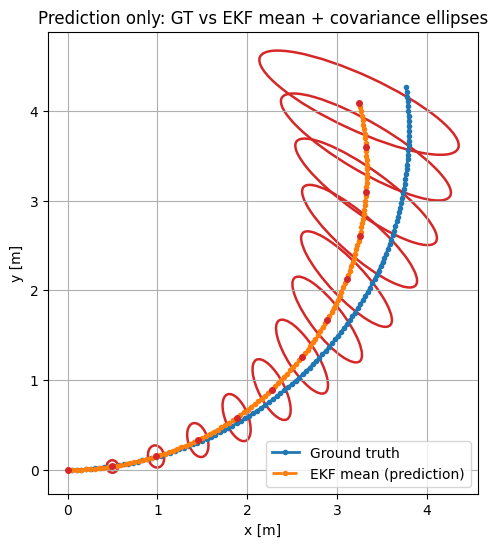

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# --- Plot utility: 2D covariance ellipse (x,y block) ---
def plot_ellipse(ax:plt.Axes, m:np.ndarray, P:np.ndarray, nsig:int = 2, **kwargs) -> None:
    """
    Draw a nsig-sigma ellipse for the (x,y) marginal of a 3x3 pose covariance.
    Args:
    - ax (plt.Axes): the axes to draw on.
    - m (np.ndarray): (3,) pose mean [x, y, theta]
    - P (np.ndarray): (3,3) pose covariance
    - nsig (int): number of standard deviations for the ellipse (default 2)
    - kwargs: additional keyword arguments passed to Ellipse patch
    """
    C = P[:2, :2]
    # Eigen-decomposition (sorted)
    S, U = np.linalg.eigh(C)
    order = S.argsort()[::-1]
    S, U = S[order], U[:, order]
    # Clamp tiny negative due to num. round-off
    S = np.clip(S, 0.0, None)
    a, b = nsig * np.sqrt(S)  # ellipse semi-axes
    ang = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
    ax.add_patch(Ellipse(xy=m[:2], width=2*a, height=2*b, angle=ang, fill=False, **kwargs))


# --- Plotting helpers ---
def plot_paths_and_ellipses(MU:np.ndarray, Sigma_hist:list, GT:np.ndarray, cfg:SimpleNamespace) -> tuple:
    """
    GT vs EKF mean + a few 2σ ellipses.
    Args:
    - MU (np.ndarray): EKF pose means over time.
    - Sigma_hist (list): EKF pose covariances over time (length T+1).
    - GT (np.ndarray): Ground-truth poses over time.
    - cfg (SimpleNamespace): configuration namespace (see above)
    Returns:
    - fig, ax : the figure and axes objects.
    """
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(GT[:, 0], GT[:, 1], '.-',  lw=2, label='Ground truth')
    ax.plot(MU[:, 0], MU[:, 1], '.--', lw=2, label='EKF mean (prediction)')

    if cfg.ellipse_steps is None:
        steps = [0, cfg.T // 3, 2 * cfg.T // 3, cfg.T]
    else:
        steps = [s for s in cfg.ellipse_steps if 0 <= s <= cfg.T]

    for s in steps:
        plot_ellipse(ax, MU[s], Sigma_hist[s], nsig=2, color='tab:red', lw=1.8)
        ax.plot(MU[s, 0], MU[s, 1], 'o', color='tab:red', ms=4)

    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.set_title('Prediction only: GT vs EKF mean + covariance ellipses')
    ax.legend(loc='best')
    return fig, ax

# --- Run + Plot ---
MU, Sigma_hist, GT = run_prediction_only(cfg)
plot_paths_and_ellipses(MU, Sigma_hist, GT, cfg)

plt.show()


我们可以发现，随着机器人步进，预测值（EKF mean）逐渐偏离真实值（ground truth），同时代表协方差的椭圆形也在慢慢变大，这表示，随着时间累积，我们对基于模型的预测是逐渐失真的，这来源于不准确动力学 (偏置和噪音)

#### 1.3 观测预测 (Observation Prediction) —— “脑补画面”

在睁开眼睛之前，你调动大脑里的记忆（上一时刻保存的地图）。你心想：“既然我刚刚往前走了一大步，如果我的预判是对的，那么现在我的右前方面前大概 1 米处，应该会出现那张我之前见过的沙发。” 根据预测的当前位置和地图中已有路标的位置，计算出传感器理论上应该输出的读数（预期距离和角度）。

对于一个之前<span style="color:#ffa500">**未观测过**</span>的 landmark, 我们根据当前机器人位姿估计与量测对其进行初始化

$$
\begin{pmatrix}
\bar{\mu}_{j,x} \\[6pt] \bar{\mu}_{j,y}
\end{pmatrix}
=
\begin{pmatrix}
\bar{\mu}_{t,x} \\[6pt] \bar{\mu}_{t,y}
\end{pmatrix}
+
\begin{pmatrix}
r_t^i \cos(\varphi_t^i + \bar{\mu}_{t,\theta}) \\[6pt]
r_t^i \sin(\varphi_t^i + \bar{\mu}_{t,\theta})
\end{pmatrix}
$$

其中：

- $\mu_{j,x}, \mu_{j,y}\,$ 为被观测路标在全局坐标系下的估计位置。
- $\bar{\mu}_{t,x}, \bar{\mu}_{t,y}\,$ 为机器人在全局坐标系下的估计位置。
- $r_t^i, \varphi_t^i\,$ 为从机器人到路标 $j$ 的相对量测。

下面，我们将根据当前估计计算<span style="color:#ffa500">**期望观测**</span> ：

$$
\begin{aligned}
\delta &=
\begin{pmatrix}
\delta_x \\[6pt] \delta_y
\end{pmatrix}
=
\begin{pmatrix}
\bar{\mu}_{j,x} - \bar{\mu}_{t,x} \\[6pt]
\bar{\mu}_{j,y} - \bar{\mu}_{t,y}
\end{pmatrix} \\[10pt]
q &= \delta^{\top}\delta \\[10pt]
\hat{z}_{t}^{i} &=
\begin{pmatrix}
\sqrt{q} \\[6pt]
\operatorname{atan2}(\delta_y,\delta_x) - \bar{\mu}_{t,\theta}
\end{pmatrix} \\[10pt]
&= h(\bar{\mu}_t)
\end{aligned}
$$

其中：
- $\delta \,$ 为机器人位姿与路标之间的相对位移向量（在全局系下由路标位置减机器人位置得到）
- $q\,$ 为欧氏距离的平方。
- $\hat{z}_t^i\,$ 将机器人与路标的状态映射为预测的观测（距离与方位）。

下面的 `expected_observation` 函数实现了根据上一节估计出的参数向量预测 landmark

In [6]:
# --- Initialization from a range–bearing observation ---
def init_landmark_from_observation(mu:np.ndarray, seen_mask:np.ndarray, j:int, z:np.ndarray) -> tuple:
    """
    If landmark j has never been seen, initialize it from the current robot pose and the range-bearing observation z = [r, phi].
    Args:
    - mu (np.ndarray): current mean state vector (robot pose + landmarks)
    - seen_mask (np.ndarray): boolean array indicating which landmarks have been seen
    - j (int): index of the landmark to initialize
    - z (np.ndarray): range-bearing observation [r, phi]
    Returns:
    - mu (np.ndarray): updated mean state vector (robot pose + landmarks)
    - seen_mask (np.ndarray): updated boolean array indicating which landmarks have been seen
    """
    if not seen_mask[j]:
        r, phi = z
        mu[3 + 2*j]     = mu[0] + r * np.cos(phi + mu[2])
        mu[3 + 2*j + 1] = mu[1] + r * np.sin(phi + mu[2])
        seen_mask[j] = True
    return mu, seen_mask

# --- Expected observation ---
def expected_observation(mu:np.ndarray, j:int) -> tuple:
    """
    Compute predicted range-bearing zhat to landmark j.
    Args:
    - mu (np.ndarray): current mean state vector (robot pose + landmarks)
    - j (int): index of the landmark
    Returns:
    - zhat (np.ndarray): predicted range-bearing observation [r, phi]
    - dx, dy (np.ndarray): difference vector from robot to landmark [dx, dy]
    - q (np.ndarray): squared range from robot to landmark
    """
    # Extract robot pose
    x, y, th = mu[:3]
    # Landmark j position
    mx, my = mu[3 + 2 * j:3 + 2 * j + 2]
    dx, dy = mx - x, my - y
    q = dx*dx + dy*dy
    r = np.sqrt(max(q, 1e-12))
    phi = wrap_angle(np.arctan2(dy, dx) - th)
    zhat = np.array([r, phi])
    return zhat, np.array([dx, dy]), q

#### 1.4 观测测量 (Measurement) —— “睁眼看世界”

你睁开眼睛（或者打开激光雷达/相机），实际测量了一下周围的环境。 传感器告诉你：“当前右前方 1.2 米处有一个物体，偏角是 15 度。”（这是带有传感器噪声的真实观测值）。


我们获得传感器的观测 $z_t$，对于一个距离——方位传感器而言, 时刻 $t$ 的第 $i$ 次观测 $ z_t^i $ 由距离 $r$ 与方位 $\varphi$ 两部分组成：

$$
z_t^i = (r_t^i, \varphi_t^i)^T
$$


#### 1.5 数据关联 (Data Association) —— “对号入座”

你开始对比步骤 2（脑补的 1 米处的沙发）和步骤 3（实际看到的 1.2 米处的物体）。你需要在心里确认：“我现在看到的这个东西，到底是我记忆里的那张沙发，还是一个我从没见过的新茶几？” 这是极度关键的一步，如果关联错误（比如把长得很像的两个柱子认错了），接下来的修正就会完全南辕北辙。通常会设定一个容错范围（马氏距离门限），如果差距在合理范围内，就认为它们是同一个物体。



我们如下假设：

- 已知数据关联（每次观测都正确对应到其路标）。
- $ t $ 时刻的观测对应路标  $ j $, 且  $ C_t^i = j $.
- 路标在首次被观测到时进行初始化。

#### 1.6 更新/校正 (Update/Correction) —— “妥协与全局收敛”

你发现“脑补的预期”和“真实的观测”之间存在 0.2 米的误差（这被称为新息 Innovation）。此时你需要做一个权衡：是我的步伐迈错了（里程计不准），还是我眼睛看花了（传感器不准），抑或是这张沙发本来就被我记错了位置（地图不准）？ 卡尔曼增益（Kalman Gain）会根据你在之前步骤中设定的各项信任度权重，强行分配这个误差。它会按比例把这 0.2 米的误差分摊掉——稍微拉扯一下你对自己位置的估计，同时稍微挪动一下地图里沙发的坐标。完成妥协后，你不仅知道了自己更准确的位置，地图的不确定性也随之缩小（协方差矩阵收缩）。

这个比例由雅可比矩阵来得到（这关系到变量之间相互影响的大小）

下面我们计算观测（测量）模型 $ h(\bar{\mu}_t) $ 的雅可比矩阵:

我们先只聚焦于非零维度  $(x,y,\theta,m_{j,x},m_{j,y})$.

$$
\begin{aligned}
{}^{\text{low}}H_{t}^{i} &=
\frac{\partial h(\bar{\mu}_t)}{\partial \bar{\mu}_t} \\[10pt]
&=
\begin{pmatrix}
\frac{\partial \sqrt{q}}{\partial x} & \frac{\partial \sqrt{q}}{\partial y} & \cdots \\
\frac{\partial \operatorname{atan2}(\cdot,\cdot)}{\partial x} & \frac{\partial \operatorname{atan2}(\cdot,\cdot)}{\partial y} & \cdots \\
\end{pmatrix}
\end{aligned}
$$

应用链式法则后得到：

$$
{}^{\text{low}}H_{t}^{i} = \frac{1}{q}
\begin{pmatrix}
-\sqrt{q}\,\delta_x & -\sqrt{q}\,\delta_y & 0 & \sqrt{q}\,\delta_x & \sqrt{q}\,\delta_y \\[6pt]
\delta_y & -\delta_x & -q & -\delta_y & \delta_x
\end{pmatrix}
$$


同样地，我们需要把它映射到完整的高维状态空间：

$$
H_{t}^{i} = {}^{\text{low}}H_{t}^{i} \, F_{x,j}
$$

其中 $F_{x,j}$ 从完整状态向量中提取机器人位姿与第 $j$ 个路标的位置

$$
F_{x,j} =
\begin{pmatrix}
1 & 0 & 0 & 0 \, \dots \, 0 & 0 & 0 & 0 \, \ldots \, 0 \\[3pt]
0 & 1 & 0 & 0 \, \dots \, 0 & 0 & 0 & 0 \, \ldots \, 0 \\[3pt]
0 & 0 & 1 & 0 \, \dots \, 0 & 0 & 0 & 0 \, \ldots \, 0 \\[3pt]
0 & 0 & 0 & 0 \, \dots \, 0 & 1 & 0 & 0 \, \ldots \, 0 \\[3pt]
0 & 0 & 0 & \underbrace{0 \, \dots \, 0}_{2j-2} & 0 & 1 & \underbrace{0 \, \ldots \, 0}_{2N-2j} \\[3pt]
\end{pmatrix}
$$

In [7]:
# --- Compute the Jacobian of the observation model ---
def H_low(mu: np.ndarray, j: int) -> tuple:
    """
    Compute the 2x5 Jacobian of the observation model.
    Args:
    - mu (np.ndarray): current mean state vector (robot pose + landmarks)
    - j (int): landmark index (0-based)
    Returns:
    - H_small (np.ndarray): (2,5) Jacobian wrt [x, y, theta, mx, my]
    - zhat (np.ndarray): (2,) expected observation [range, bearing]
    """
    zhat, delta, q = expected_observation(mu, j)
    dx, dy = delta
    r = zhat[0]
    q = max(q, 1e-12)  # guard
    H_small = (1.0/q) * np.array([
        [-r*dx,  -r*dy,   0.0,  r*dx,  r*dy],
        [  dy,    -dx,   -q,    -dy,    dx]
    ])
    return H_small, zhat

# --- Auxiliary matrix to map into full state size ---
def Fxj_embed(n:int, j:int) -> np.ndarray:
    """
    Create the auxiliary matrix Fxj to embed 5x5 matrices into the state vector of size n.
    Args:
    - n (int): size of the full state (robot + landmarks)
    - j (int): landmark index (0-based)
    Returns:
    - Fxj (np.ndarray): (5,n) matrix to map 5x5 into full state size
    """
    Fxj = np.zeros((5, n))
    Fxj[:3,:3] = np.eye(3)
    Fxj[3, 3+2*j]   = 1.0
    Fxj[4, 3+2*j+1] = 1.0
    return Fxj

# --- Full Jacobian of the observation model ---
def H_full(mu: np.ndarray, j: int) -> tuple:
    """
    Expand H_low into full state size using Fxj_embed.
    Args:
    - mu (np.ndarray): current mean state vector (robot pose + landmarks)
    - j (int): landmark index (0-based)
    Returns:
    - H_i (np.ndarray): (2,n) Jacobian wrt full state vector
    - zhat (np.ndarray): (2,) expected observation [range, bearing]
    """
    n = mu.size
    H_small, zhat = H_low(mu, j)
    Fxj = Fxj_embed(n, j)
    H_i = H_small @ Fxj
    return H_i, zhat

#### 1.7 EKF 校正：组合 1.3-1.6 的步骤

In [8]:
# --- Innovation ---
def innovation(z: np.ndarray, zhat: np.ndarray) -> np.ndarray:
    """
    Innovation, the difference between actual and expected observation.
    Args:
    - z (np.ndarray): actual observation [r, phi]
    - zhat (np.ndarray): expected observation [r, phi]
    Returns:
    - v (np.ndarray): innovation difference [dr, dphi] with bearing wrapped to (-pi, pi]
    """
    return np.array([z[0] - zhat[0], wrap_angle(z[1] - zhat[1])])

# --- EKF SLAM Correction Step ---
def EKF_SLAM_Correction(mu_bar: np.ndarray, Sigma_bar: np.ndarray, z_list: list, c_list: list, Q: np.ndarray, seen_mask: np.ndarray) -> tuple:
    """
    EKF-SLAM correction step.
    Args:
    - mu_bar (np.ndarray): predicted mean state vector (robot pose + landmarks)
    - Sigma_bar (np.ndarray): predicted covariance matrix
    - z_list (list): list of range-bearing observations [r, phi]
    - c_list (list): list of landmark indices corresponding to z_list (0-based)
    - Q (np.ndarray): observation noise covariance matrix
    - seen_mask (np.ndarray): boolean array indicating which landmarks have been seen
    Returns:
    - mu (np.ndarray): updated mean state vector (robot pose + landmarks)
    - Sigma (np.ndarray): updated covariance matrix
    - seen_mask (np.ndarray): updated boolean array indicating which landmarks have been seen
    """
    mu    = mu_bar.copy()
    Sigma = Sigma_bar.copy()
    I     = np.eye(mu.size)
    # Process each observation
    for z, j in zip(z_list, c_list):
        # Initialize unseen landmarks
        mu, seen_mask = init_landmark_from_observation(mu, seen_mask, j, z)
        # Expected observation and Jacobians
        H_small, zhat = H_low(mu, j)
        # Full-state Jacobian H_i (2xn) via Fxj
        n = mu.size
        Fxj = Fxj_embed(n, j)
        H_i = H_small @ Fxj
        # Kalman gain
        S = H_i @ Sigma @ H_i.T + Q
        v = innovation(z, zhat)
        K = Sigma @ H_i.T @ np.linalg.inv(S)
        # Update state and covariance
        mu    = mu + K @ v
        mu[2] = wrap_angle(mu[2])     # normalize heading
        Sigma = (I - K @ H_i) @ Sigma
    return mu, Sigma, seen_mask

#### 1.8 EKF-SLAM：组合 1.2 和 1.7 的步骤

通过组合 1.2 中的状态估计和 1.7 中的根据实际观测进行状态校正这两部分，我们得到完整的 EKF-SLAM 的算法流程：

请记住，我们的总体目标是：根据 t-1 时刻的状态对 t 时刻的状态做出估计，接着利用 t 时刻的观测到的 landmark 对估计做出修正。其中，修正项被称为卡尔曼增益（Kalman Gain）。

> <tt> <span style="color:#FF2DD1">1.</span> <span style="color:#4D96FF">def</span> **<span style="color:#6BCB77">EKF_SLAM_Prediction</span>($\color{#ffa500}\mu_{t-1}$, $\color{#ffa500}\Sigma_{t-1}$, $\color{#ffa500}u_t$, $\color{#ffa500}z_t$, $\color{#ffa500}c_t$, $\color{#ffa500}R_t$):**
>>
>><span style="color:#FF2DD1">2.</span> $F_x =  
\begin{pmatrix}
1 & 0 & 0 & 0 \, \ldots \, 0 \\
0 & 1 & 0 & 0 \, \ldots \, 0 \\
0 & 0 & 1 & 0 \, \ldots \, 0 \\
\end{pmatrix}\,\,\,\,$ <span style="color:#948979"> # 定义到完整状态空间的投影（ robot --> robot + landmarks）</span>
>>
>><span style="color:#FF2DD1">3.</span> $\bar{\mu}_t = \bar{\mu}_{t-1} + F_x^T
\begin{pmatrix}
-\frac{v_t}{w_t}\sin \mu_{t-1,\theta} + \frac{v_t}{w_t}\sin(\mu_{t-1,\theta} + w_t\Delta t) \\[6pt]
\frac{v_t}{w_t}\cos \mu_{t-1,\theta} - \frac{v_t}{w_t}\cos(\mu_{t-1,\theta} + w_t\Delta t) \\[6pt]
w_t\Delta t
\end{pmatrix}\,\,\,\,$ <span style="color:#948979"># 预测均值 </span>
>>
>><span style="color:#FF2DD1">4.</span> $G_t = I + F_x^T
\begin{pmatrix}
0 & 0 & -\frac{v_t}{w_t}\cos \mu_{t-1,\theta} + \frac{v_t}{w_t}\cos(\mu_{t-1,\theta} + w_t\Delta t) \\[6pt]
0 & 0 & -\frac{v_t}{w_t}\sin \mu_{t-1,\theta} + \frac{v_t}{w_t}\sin(\mu_{t-1,\theta} + w_t\Delta t) \\[6pt]
0 & 0 & 0
\end{pmatrix} F_x\,\,\,\,$ <span style="color:#948979"># 计算雅可比矩阵（线性化）</span>
>>
>><span style="color:#FF2DD1">5.</span> $\bar{\Sigma}_t = G_t \Sigma_{t-1} G_t^T + \underbrace{F_x^T R_t^x F_x}_{R_t} \,\,\,\,$ <span style="color:#948979"># 计算协方差矩阵</span>
>>
>><span style="color:#FF2DD1">6.</span> <span style="color:#e74c3c">return</span> $\bar{\mu}_t,\,\bar{\Sigma}_t$
>
><span style="color:#FF2DD1">7.</span> <span style="color:#4D96FF">def</span> **<span style="color:#6BCB77">EKF_SLAM_Correction</span>($\color{#ffa500}\bar{\mu}_t$, $\color{#ffa500}\bar{\Sigma}_t$, $\color{#ffa500}u_t$, $\color{#ffa500}z_t$, $\color{#ffa500}c_t$, $\color{#ffa500}\sigma_t$):**
>>
>><span style="color:#FF2DD1">8.</span> $Q_t = \begin{pmatrix} \sigma_r^2 & 0 \\ 0 & \sigma_\phi^2 \\ \end{pmatrix} \,\,\,\,$ <span style="color:#948979"># 定义传感器的观测噪音 </span>
>>
>><span style="color:#FF2DD1">9.</span> <span style="color:#e74c3c">for all</span> <span style="color:#ffa500">observed features</span> $z_t^i = (r_t^i,\phi_t^i)^T$ <span style="color:#e74c3c">do</span>:
>>
>>><span style="color:#FF2DD1">10.</span> $j = c_t^i\,\,\,\,$ <span style="color:#948979"># 索引特征点（特征点关联）</span>
>>>
>>><span style="color:#FF2DD1">11.</span> <span style="color:#e74c3c">if</span> <span style="color:#ffa500">landmark</span> $j$ <span style="color:#e74c3c"> never seen before</span>:
>>>>
>>>><span style="color:#FF2DD1">12.</span> $\begin{pmatrix} \bar{\mu}_{j,x} \\[6pt] \bar{\mu}_{j,y} \end{pmatrix} = \begin{pmatrix} \bar{\mu}_{t,x} \\[6pt] \bar{\mu}_{t,y}\end{pmatrix} + \begin{pmatrix} r_t^i \cos(\varphi_t^i + \bar{\mu}_{t,\theta}) \\[6pt] r_t^i \sin(\varphi_t^i + \bar{\mu}_{t,\theta}) \end{pmatrix}\,\,\,\,$ <span style="color:#948979"># 根据机器人位置初始化 landmark </span>
>>>>
>>><span style="color:#FF2DD1">13.</span> <span style="color:#e74c3c">endif</span>
>>>
>>><span style="color:#FF2DD1">14.</span> $\delta = \begin{pmatrix} \delta_x \\[6pt] \delta_y \end{pmatrix} = \begin{pmatrix} \bar{\mu}_{j,x} - \bar{\mu}_{t,x} \\[6pt] \bar{\mu}_{j,y} - \bar{\mu}_{t,y} \end{pmatrix}\,\,\,\,$ <span style="color:#948979"># 计算到 landmark 的距离</span>
>>>
>>><span style="color:#FF2DD1">15.</span> $q = \delta^T \delta\,\,\,\,$ <span style="color:#948979"># 计算欧几里得距离 </span>
>>>
>>><span style="color:#FF2DD1">16.</span> $\hat{z}_t^i = \begin{pmatrix} \sqrt{q} \\[6pt] \text{atan2}(\delta_y,\delta_x) - \bar{\mu}_{t,\theta} \end{pmatrix}\,\,\,\,$ <span style="color:#948979"># 计算预测的观测</span>
>>>
>>><span style="color:#FF2DD1">17.</span> $F_{x,j} = \begin{pmatrix} 1 & 0 & 0 & 0 \, \dots \, 0 & 0 & 0 & 0 \, \ldots \, 0 \\[3pt] 0 & 1 & 0 & 0 \, \dots \, 0 & 0 & 0 & 0 \, \ldots \, 0 \\[3pt] 0 & 0 & 1 & 0 \, \dots \, 0 & 0 & 0 & 0 \, \ldots \, 0 \\[3pt] 0 & 0 & 0 & 0 \, \dots \, 0 & 1 & 0 & 0 \, \ldots \, 0 \\[3pt] 0 & 0 & 0 & \underbrace{0 \, \dots \, 0}_{2j-2} & 0 & 1 & \underbrace{0 \, \ldots \, 0}_{2N-2j} \\[3pt] \end{pmatrix}\,\,\,\,$ <span style="color:#948979"># 映射到完整的状态空间中 </span>
>>>
>>><span style="color:#FF2DD1">18.</span> $H_t^{i} = \frac{1}{q} \begin{pmatrix} -\sqrt{q}\,\delta_x & -\sqrt{q}\,\delta_y & 0 & \sqrt{q}\,\delta_x & \sqrt{q}\,\delta_y \\[6pt] \delta_y & -\delta_x & -q & -\delta_y & \delta_x \end{pmatrix} F_{x,j} \,\,\,\,$ <span style="color:#948979"># 计算观测的雅可比矩阵</span>
>>>
>>><span style="color:#FF2DD1">19.</span> $K_t^i = \bar{\Sigma}_t \, H_t^{iT} \,(H_t^i \, \bar{\Sigma}_t \, H_t^{iT} + Q_t) ^{-1}\,\,\,\,$ <span style="color:#948979"># 计算卡尔曼增益 </span>
>>>
>>><span style="color:#FF2DD1">20.</span> $\bar{\mu}_t = \bar{\mu}_t + K_t^i(z_t^i - \hat{z_t}^i)\,\,\,\,$ <span style="color:#948979"># 更新状态变量均值</span>
>>>
>>><span style="color:#FF2DD1">21.</span> $\bar{\Sigma}_t = (I - K_t^i \, H_t^i) \, \bar{\Sigma}_t\,\,\,\,$ <span style="color:#948979"># 更新状态变量方差</span>
>>>
>><span style="color:#FF2DD1">22.</span> <span style="color:#e74c3c">endfor</span>
>>
>><span style="color:#FF2DD1">23.</span> $\mu_t = \bar{\mu}_t\,\,\,\,$
>>
>><span style="color:#FF2DD1">24.</span> $\Sigma_t = \bar{\Sigma}_t\,\,\,\,$
>>
>><span style="color:#FF2DD1">25.</span> <span style="color:#e74c3c">return</span> $\mu_t, \Sigma_t\,\,\,\,$
</tt>

In [9]:
# --- Sampling & plotting utils --
def sample_landmarks(N:int, lo:np.ndarray, hi:np.ndarray, min_dist:float, seed:int=None) -> np.ndarray:
    """
    Sample N landmark positions uniformly in [lo, hi]x[lo, hi],
    ensuring they are at least min_dist from the origin.
    Args:
        N (int): number of landmarks
        lo (np.ndarray): lower bound (2,)
        hi (np.ndarray): upper bound (2,)
        min_dist (float): minimum distance from origin
        seed (int, optional): random seed. Defaults to None.
    Returns:
        L (np.ndarray): (N,2) landmark positions
    """
    rng = np.random.default_rng(seed)
    L = rng.uniform(low=lo, high=hi, size=(N, 2))
    mask = np.linalg.norm(L, axis=1) > min_dist
    while not np.all(mask):
        L[~mask] = rng.uniform(low=lo, high=hi, size=(np.sum(~mask), 2))
        mask = np.linalg.norm(L, axis=1) > min_dist
    return L

def circular_trajectory_controls(T:int, speed:np.ndarray) -> list:
    """
    Generate a list of (v,w) controls to follow a circular trajectory.
    Args:
        T (int): number of time steps
        speed (np.ndarray): nominal (v,w) speeds
    Returns:
        list: list of (v,w) controls for T steps
    """
    v, w = float(speed[0]), float(speed[1])
    return [np.array([v, w]) for _ in range(T)]

# --- Full example (prediction + correction) ---
cfg = SimpleNamespace(
    seed          = 1,                         # set to None for nondeterministic runs
    N_landmarks   = 4,                         # 路标数量
    lm_bounds_lo  = np.array([ 0.0, 0.0]),     # 路标采样下界
    lm_bounds_hi  = np.array([ 5.0, 5.0]),     # 路标采样上界
    lm_min_dist   = 0.5,                       # 路标距原点的最小距离
    dt            = 0.10,                      # 时间步长 [s]
    T             = 120,                       # 步数
    u_nom         = np.array([0.50, 0.15]),    # EKF 预测控制量
    R_x           = np.diag([0.01**2, 0.01**2, # EKF [x, y, theta] 过程噪声
                            (1.0*np.pi/180)**2]),
    Q             = np.diag([0.02**2,          # EKF [r, phi] 观测噪声
                            (2.0*np.pi/180)**2]),
    bias_v        = 1.07,                      # 真值速度偏置倍率
    bias_w        = 0.96,                      # 真值角速度偏置倍率
    R_exec        = np.diag([0.02**2,          # 真值 [v, w] 控制噪声
                            (2.0*np.pi/180)**2]),
    Sigma0_pose   = np.diag([1e-4, 1e-4,       # 初始位姿协方差
                            (1*np.pi/180)**2]),
    Sigma0_lm_var = 1e6,                       # 初始路标方差（很大≈无信息先验）
    ellipse_steps = np.arange(0, 121, 10),     # 画椭圆的步；None 为自动
)

# --- Full EKF-SLAM rollout ---
def run_full_stack(cfg):
    # Landmarks & controls
    L_true = sample_landmarks(cfg.N_landmarks, cfg.lm_bounds_lo, cfg.lm_bounds_hi, cfg.lm_min_dist, seed=cfg.seed)
    u_seq  = circular_trajectory_controls(cfg.T, cfg.u_nom)

    # Initial belief
    n = 3 + 2*cfg.N_landmarks
    mu    = np.zeros(n)
    Sigma = np.block([
        [cfg.Sigma0_pose, np.zeros((3, 2*cfg.N_landmarks))],
        [np.zeros((2*cfg.N_landmarks, 3)), np.eye(2*cfg.N_landmarks)*cfg.Sigma0_lm_var]
    ])
    seen = np.zeros(cfg.N_landmarks, dtype=bool)

    # Ground truth
    x_gt = np.zeros(3)

    # Logs
    MU_hist, GT_hist = [mu.copy()], [x_gt.copy()]
    Ppose_hist = [Sigma[:3,:3].copy()]

    rng = np.random.default_rng(cfg.seed)
    for k in range(cfg.T):
        # --- GT executes biased + noisy controls
        noise  = rng.multivariate_normal([0,0], cfg.R_exec)
        u_exec = np.array([cfg.bias_v*cfg.u_nom[0], cfg.bias_w*cfg.u_nom[1]]) + noise
        x_gt[:3] = x_gt[:3] + motion_increment(x_gt[2], u_exec, cfg.dt)
        x_gt[2]  = wrap_angle(x_gt[2])

        # --- Prediction ---
        mu_bar, Sigma_bar = EKF_SLAM_Prediction(mu, Sigma, u_seq[k], cfg.R_x, cfg.dt)

        # --- Measurements (all landmarks, known associations)
        z_all, c_all = [], []
        for j in range(cfg.N_landmarks):
            dx, dy = L_true[j,0] - x_gt[0], L_true[j,1] - x_gt[1]
            r      = np.hypot(dx, dy)
            phi    = wrap_angle(np.arctan2(dy, dx) - x_gt[2])
            z = np.array([
                r   + rng.normal(0.0, np.sqrt(cfg.Q[0,0])),
                wrap_angle(phi + rng.normal(0.0, np.sqrt(cfg.Q[1,1])))
            ])
            z_all.append(z); c_all.append(j)

        # --- Correction ---
        mu, Sigma, seen = EKF_SLAM_Correction(
            mu_bar, Sigma_bar, z_all, c_all, cfg.Q, seen)

        # --- Log ---
        MU_hist.append(mu.copy()); GT_hist.append(x_gt.copy())
        Ppose_hist.append(Sigma[:3,:3].copy())

    return np.vstack(MU_hist), np.vstack(GT_hist), Ppose_hist, L_true


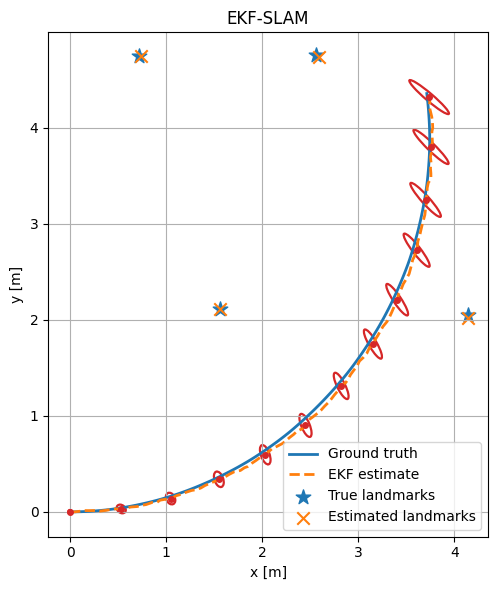

In [10]:
# --- Run & plot ---
MU_hist, GT_hist, Ppose_hist, L_true = run_full_stack(cfg)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Trajectories + ellipses
ax.plot(GT_hist[:,0], GT_hist[:,1], '-',  lw=2, label='Ground truth')
ax.plot(MU_hist[:,0], MU_hist[:,1], '--', lw=2, label='EKF estimate')
for s in cfg.ellipse_steps:
    plot_ellipse(ax, MU_hist[s], Ppose_hist[s], nsig=2, color='tab:red', lw=1.6)
    ax.plot(MU_hist[s,0], MU_hist[s,1], 'o', color='tab:red', ms=4)
ax.scatter(L_true[:,0], L_true[:,1], marker='*', s=120, label='True landmarks')
estL = MU_hist[-1, 3:].reshape(-1, 2)
ax.scatter(estL[:,0], estL[:,1], marker='x', s=80, label='Estimated landmarks')
ax.set_aspect('equal', adjustable='box')
ax.grid(True); ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
ax.set_title(f'EKF-SLAM')
ax.legend(loc='best')

plt.tight_layout(); plt.show()

对比未经卡尔曼增益修正的估计（1.2 节），是不是相对真实值的轨迹误差小了很多，同时方差也收缩了很多。

#### 1.9 🤖 在简单的仿真环境中尝试吧

下面提供一套基于 pygame 的简单仿真环境实现，在这里，我们不做高层特征提取，而是把每个 LiDAR 点都当作潜在路标。但是这会面临一个问题：状态向量会迅速膨胀，带来计算瓶颈。为此，我们将 2D LiDAR 成像平面离散成像素块，每块只保留一个路标，从而显著减少路标总数。

同时，每步用全部路标更新整个状态向量代价很高。因此我们只更新距离最近的一小部分路标，在保持效率的同时，仍能在路标被反复观测时持续修正地图。

In [11]:
# ===========================================
# EKF-SLAM Pygame Demo (GT left | EKF right)
# ===========================================

import os
import sys

import pygame
from typing import Optional

# Colab / headless: must be set before `import pygame` (restart runtime if toggling).
try:
    import google.colab  # type: ignore[import-not-found]
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False
if _IN_COLAB or os.environ.get("HELLO_SLAM_HEADLESS") == "1":
    os.environ.setdefault("SDL_VIDEODRIVER", "dummy")

# --- Small helpers ---
def wrap_angle(a: float) -> float:
    return (a + np.pi) % (2*np.pi) - np.pi

def i2(p):
    """(x,y) -> (int,int)"""
    return (int(p[0]), int(p[1]))


def ensure_floor_plan_image(cfg: "Config") -> str:
    """Return an absolute path to a floor-plan PNG: prefer local files, else download cfg.floor_plan_url."""
    from urllib.error import HTTPError, URLError
    from urllib.request import Request, urlopen

    candidates: list = []
    if getattr(cfg, "floor_img_path", None):
        candidates.append(str(cfg.floor_img_path))
    for rel in ("../figures/floor_plan.png", "figures/floor_plan.png", "floor_plan.png"):
        if rel not in candidates:
            candidates.append(rel)

    for p in candidates:
        if p and os.path.isfile(p):
            return os.path.abspath(p)

    url = getattr(cfg, "floor_plan_url", None)
    if not url:
        raise FileNotFoundError(
            "No floor plan PNG found. Options: (1) Upload PNG to Colab (/content) and set "
            "Config.floor_img_path, e.g. '/content/floor_plan.png'. "
            "(2) Set Config.floor_plan_url to a direct HTTPS link to the PNG."
        )

    cache = getattr(cfg, "floor_plan_cache_path", None) or os.path.join(
        os.getcwd(), "floor_plan_downloaded.png"
    )
    cache = os.path.abspath(cache)
    parent = os.path.dirname(cache)
    if parent:
        os.makedirs(parent, exist_ok=True)

    req = Request(url, headers={"User-Agent": "Mozilla/5.0 (compatible; EKF-SLAM-demo/1.0)"})
    try:
        with urlopen(req, timeout=120) as resp:
            data = resp.read()
    except (URLError, HTTPError) as e:
        raise RuntimeError(f"Failed to download floor_plan_url: {e}") from e

    with open(cache, "wb") as f:
        f.write(data)
    return cache


# --- Config ---
class Config:
    # Window/panels
    panel_w, panel_h = 600, 400
    window_size = (panel_w*2, panel_h)

    # Scan/visual
    num_beams = 180
    scan_ms   = 100
    fov_deg   = 360
    ray_stride = 2
    traj_max   = 200

    # Discretization (to limit LMs)
    grid_px = 8           # one LM per grid cell
    range_step_px = 4.0   # quantize range
    bearing_step_deg = 2.0
    bearing_step = np.deg2rad(bearing_step_deg)

    # Landmark selection
    use_nearest = True
    nearest_k_seen = 25
    chunk = None          # None or e.g. 24

    # Motion (keyboard odometry)
    trans_step = 10.0
    rot_step   = np.deg2rad(15.0)

    # ipywidgets Play interval (ms): beam animation + PNG refresh in Jupyter/Colab
    widget_play_interval_ms = 50

    # GT panel LiDAR viz: full fan looks good at low widget FPS; sweep Hz avoids angle undersampling
    viz_fan_rays = 72
    beam_sweep_hz_desktop = 10.0
    beam_sweep_hz_notebook = 0.65

    # Noises (pixels & radians)
    R_x = np.diag([1.0**2, 1.0**2, (2.0*np.pi/180.0)**2]).astype(np.float32)  # process (pose)
    Q   = np.diag([2.0**2, (2.0*np.pi/180.0)**2]).astype(np.float32)          # sensor (range px, bearing rad)

    # Floor plan PNG: local file first (see ensure_floor_plan_image); if absent, download floor_plan_url.
    floor_img_path = "floor_plan.png"
    # Direct image URL (not the imgbb gallery page). Used when no local candidate exists (e.g. Colab /content).
    floor_plan_url = "https://i.ibb.co/BKT1C2Lt/floor-plan.png"
    floor_plan_cache_path = None  # None -> <cwd>/floor_plan_downloaded.png; optional e.g. "/content/floor_plan.png" on Colab

# --- Panel (drawing with offset) ---
class Panel:
    def __init__(self, screen, rect):
        self.screen = screen
        self.rect   = rect     # (x,y,w,h)

    @property
    def ox(self): return self.rect[0]

    def clear(self, color):
        x,y,w,h = self.rect
        self.screen.fill(color, self.rect)
        pygame.draw.rect(self.screen, (200,200,200), self.rect, 2)

    def blit(self, surf, at=(0,0)):
        x,y,_,_ = self.rect
        self.screen.blit(surf, (x+at[0], y+at[1]))

    def line(self, color, p0, p1, width=1):
        x,y,_,_ = self.rect
        self.screen.draw_line = pygame.draw.line
        pygame.draw.line(self.screen, color, (x+p0[0], y+p0[1]), (x+p1[0], y+p1[1]), width)

    def circle(self, color, p, r):
        x,y,_,_ = self.rect
        pygame.draw.circle(self.screen, color, (x+int(p[0]), y+int(p[1])), r)

    def polygon(self, color, pts):
        x,y,_,_ = self.rect
        P = [(x+int(px), y+int(py)) for (px,py) in pts]
        pygame.draw.polygon(self.screen, color, P)

    def text(self, font, s, color, pos):
        x,y,_,_ = self.rect
        self.screen.blit(font.render(s, True, color), (x+pos[0], y+pos[1]))

# --- Map / occupancy ---
class Map2D:
    def __init__(self, cfg: Config, floor_img_path: Optional[str] = None) -> None:
        self.cfg = cfg
        path = floor_img_path if floor_img_path is not None else ensure_floor_plan_image(cfg)
        self.surface = pygame.transform.smoothscale(
            pygame.image.load(path), (cfg.panel_w, cfg.panel_h)
        )
        arr = pygame.surfarray.array3d(self.surface)  # (w,h,3)
        self.wall_mask = np.all(arr < 128, axis=2).astype(np.bool_)  # True=wall

    def cast_beam_fast(self, pos_xy, angle, max_r):
        W, H = self.wall_mask.shape
        x0, y0 = float(pos_xy[0]), float(pos_xy[1])
        c, s = np.cos(angle), np.sin(angle)
        for d in range(0, int(max_r), self.cfg.ray_stride):
            x = int(x0 + d*c); y = int(y0 + d*s)
            if not (0 <= x < W and 0 <= y < H):  # left/top clipped by panel bounds
                return None, d
            if self.wall_mask[x, y]:
                return (x, y), d
        return None, int(max_r)

# --- LiDAR (ID per grid cell) ---
class Lidar:
    def __init__(self, cfg: Config, world_map: Map2D):
        self.cfg = cfg
        self.map = world_map
        self.id_by_cell = {}   # (cx,cy) -> lm_id
        self.cell_by_id = []   # list indexed by lm_id: (cx,cy)

    def cell_of_xy(self, x: float, y: float):
        return (int(x)//self.cfg.grid_px, int(y)//self.cfg.grid_px)

    def cell_center_xy(self, cell):
        cx, cy = cell
        g = self.cfg.grid_px
        return (cx*g + 0.5*g, cy*g + 0.5*g)

    def quantize_meas(self, r: float, phi: float):
        rq = self.cfg.range_step_px * round(r / self.cfg.range_step_px)
        pq = wrap_angle(self.cfg.bearing_step * round(phi / self.cfg.bearing_step))
        return rq, pq

    def ensure_id(self, cell):
        if cell not in self.id_by_cell:
            lm_id = len(self.cell_by_id)
            self.id_by_cell[cell] = lm_id
            self.cell_by_id.append(cell)
        return self.id_by_cell[cell]

    def scan(self, gt_pose, heading, rng, max_range_px=200):
        fov = np.deg2rad(self.cfg.fov_deg)
        angles = (heading + np.linspace(-fov/2, fov/2, self.cfg.num_beams, endpoint=False)) % (2*np.pi)

        z_all, c_all = [], []
        used_cells = set()
        for a in angles:
            hit, dist = self.map.cast_beam_fast(gt_pose[:2], a, max_range_px)
            if not hit:
                continue
            hx, hy = hit
            cell = self.cell_of_xy(hx, hy)
            if cell in used_cells:
                continue
            used_cells.add(cell)

            j = self.ensure_id(cell)

            # noisy (r,phi) relative to GT, quantized
            true_phi = wrap_angle(a - float(gt_pose[2]))
            r_meas   = dist  + rng.normal(0.0, np.sqrt(float(self.cfg.Q[0,0])))
            phi_meas = wrap_angle(true_phi + rng.normal(0.0, np.sqrt(float(self.cfg.Q[1,1]))))
            r_q, phi_q = self.quantize_meas(r_meas, phi_meas)

            z_all.append(np.array([r_q, phi_q], dtype=np.float32))
            c_all.append(j)

        return z_all, c_all

# --- EKF-SLAM (odometry + range/bearing) ---
class EKFSLAM:
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.mu    = None          # [x,y,th, m1x,m1y, ...]
        self.Sigma = None
        self.seen  = None

    # --- state sizing ---
    def ensure_state_size(self, N: int, init_pose=None):
        req_n = 3 + 2*N
        if self.mu is None:
            self.mu = np.zeros(req_n, dtype=np.float32)
            if init_pose is not None:
                self.mu[:3] = init_pose
            self.Sigma = np.block([
                [np.diag([1e-6, 1e-6, (1*np.pi/180.0)**2]).astype(np.float32), np.zeros((3, 2*N), dtype=np.float32)],
                [np.zeros((2*N, 3), dtype=np.float32), np.eye(2*N, dtype=np.float32)*1e6]
            ])
            self.seen = np.zeros(N, dtype=bool)
            return
        currN = (self.mu.size - 3)//2
        if N > currN:
            addN = N - currN
            self.mu = np.hstack([self.mu, np.zeros(2*addN, dtype=np.float32)])
            top = np.hstack([self.Sigma, np.zeros((3+2*currN, 2*addN), dtype=np.float32)])
            bot = np.hstack([np.zeros((2*addN, 3+2*currN), dtype=np.float32), np.eye(2*addN, dtype=np.float32)*1e6])
            self.Sigma = np.vstack([top, bot])
            self.seen = np.hstack([self.seen, np.zeros(addN, dtype=bool)])

    def ensure_state(self, lidar: Lidar, init_pose=None):
        self.ensure_state_size(len(lidar.cell_by_id), init_pose=init_pose)

    # --- motion (odometry) ---
    @staticmethod
    def motion_model_odometry(u, x_prev):
        dr1, dt, dr2 = u
        x_new = x_prev[0] + dt*np.cos(x_prev[2] + dr1)
        y_new = x_prev[1] + dt*np.sin(x_prev[2] + dr1)
        th_new= wrap_angle(x_prev[2] + dr1 + dr2)
        return np.array([x_new, y_new, th_new], dtype=np.float32)

    @staticmethod
    def G_inner_odometry(th, u):
        dr1, dt, _ = u
        c = np.cos(th + dr1); s = np.sin(th + dr1)
        return np.array([[0,0,-dt*s],[0,0,dt*c],[0,0,0]], dtype=np.float32)

    def predict(self, u):
        mu_pred = self.mu.copy()
        mu_pred[:3] = self.motion_model_odometry(u, self.mu[:3])
        mu_pred[2]  = wrap_angle(float(mu_pred[2]))

        Σ_xx = self.Sigma[:3,:3]
        Σ_xm = self.Sigma[:3,3:]
        Gx = np.eye(3, dtype=np.float32) + self.G_inner_odometry(float(self.mu[2]), u)

        Σ_xx_new = Gx @ Σ_xx @ Gx.T + self.cfg.R_x
        Σ_xm_new = Gx @ Σ_xm

        Sigma_pred = self.Sigma.copy()
        Sigma_pred[:3,:3] = Σ_xx_new
        Sigma_pred[:3,3:] = Σ_xm_new
        Sigma_pred[3:,:3] = Σ_xm_new.T

        self.mu, self.Sigma = mu_pred, Sigma_pred

    # --- observation / correction ---
    @staticmethod
    def innovation(z, zhat):
        return np.array([float(z[0]) - float(zhat[0]), wrap_angle(float(z[1]) - float(zhat[1]))], dtype=np.float32)

    def expected_observation(self, j):
        x,y,th = float(self.mu[0]), float(self.mu[1]), float(self.mu[2])
        mx,my  = float(self.mu[3+2*j]), float(self.mu[3+2*j+1])
        dx,dy  = mx-x, my-y
        q      = dx*dx + dy*dy
        r      = np.sqrt(max(q, 1e-12))
        phi    = wrap_angle(np.arctan2(dy,dx) - th)
        return np.array([r,phi], dtype=np.float32), np.array([dx,dy], dtype=np.float32), float(q)

    def init_landmark_at_xy(self, j, xy):
        if not self.seen[j]:
            self.mu[3+2*j]   = float(xy[0])
            self.mu[3+2*j+1] = float(xy[1])
            self.seen[j] = True

    def correct_batch(self, z_list, c_list, lidar: Lidar):
        n = self.mu.size
        I = np.eye(n, dtype=np.float32)

        M = len(z_list)
        if M == 0: return

        # 1) init unseen LMs at cell centers
        for z, j in zip(z_list, c_list):
            if not self.seen[j]:
                cell = lidar.cell_by_id[j]
                cx,cy = lidar.cell_center_xy(cell)
                self.init_landmark_at_xy(j, (cx,cy))

        # 2) stack H, v
        H = np.zeros((2*M, n), dtype=np.float32)
        v = np.zeros(2*M, dtype=np.float32)
        for i, (z, j) in enumerate(zip(z_list, c_list)):
            zhat, delta, q = self.expected_observation(j)
            dx,dy = float(delta[0]), float(delta[1]); r = float(zhat[0]); q = max(q, 1e-12)
            Hs = (1.0/q) * np.array([
                [-r*dx,  -r*dy,   0.0,  r*dx,  r*dy],
                [  dy,    -dx,   -q,    -dy,    dx]
            ], dtype=np.float32)
            r0 = 2*i
            H[r0:r0+2, 0:3] = Hs[:,0:3]
            cj = 3 + 2*j
            H[r0:r0+2, cj:cj+2] = Hs[:,3:5]
            v[r0:r0+2] = self.innovation(z, zhat)

        R = np.kron(np.eye(M, dtype=np.float32), self.cfg.Q.astype(np.float32))
        S = H @ self.Sigma @ H.T + R
        V = self.Sigma @ H.T
        X = np.linalg.solve(S, V.T).T
        self.mu = self.mu + X @ v
        self.mu[2] = wrap_angle(float(self.mu[2]))
        self.Sigma = (I - X @ H) @ self.Sigma

    # nearest-K seen for load shedding
    def select_nearest_seen(self, max_k):
        ids = np.where(self.seen)[0]
        if ids.size == 0: return ids
        robot_xy = self.mu[:2].astype(np.float32)
        L = self.mu[3:].reshape(-1,2).astype(np.float32)[ids]
        d = np.linalg.norm(L - robot_xy[None,:], axis=1)
        order = np.argsort(d)
        return ids[order[:min(max_k, ids.size)]]

pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [12]:
# --- App ---
import io
import os


class App:
    def __init__(self, cfg: Config, use_display: bool = True) -> None:
        pygame.init()
        self.cfg = cfg
        self.use_display = use_display
        if use_display:
            self.screen = pygame.display.set_mode(cfg.window_size)
            pygame.display.set_caption("GT (left) | EKF-SLAM (right)")
        else:
            if os.environ.get("SDL_VIDEODRIVER") == "dummy":
                self.screen = pygame.display.set_mode(cfg.window_size)
            else:
                self.screen = pygame.Surface(cfg.window_size)

        self.clock = pygame.time.Clock()
        self.font = pygame.font.SysFont(None, 18)

        self.left = Panel(self.screen, (0, 0, cfg.panel_w, cfg.panel_h))
        self.right = Panel(self.screen, (cfg.panel_w, 0, cfg.panel_w, cfg.panel_h))

        self.map = Map2D(cfg)
        self.lidar = Lidar(cfg, self.map)

        self.gt_pose = np.array([cfg.panel_w // 2, cfg.panel_h // 2, 0.0], dtype=np.float32)
        self.gt_traj = [self.gt_pose.copy()]

        self.ekf = EKFSLAM(cfg)
        self.ekf.ensure_state(self.lidar, init_pose=self.gt_pose)

        self.ekf_traj = []

        hz = cfg.beam_sweep_hz_desktop if use_display else cfg.beam_sweep_hz_notebook
        self.beam_speed = 2 * np.pi * hz
        self.beam_angle = 0.0
        self.max_range_px = 200

        self._scan_accum_ms = 0
        self._hud_fps_notebook = 0.0

        self.rng = np.random.default_rng(0)

    # --- input / steps ---
    def step_motion(self, cmd: np.ndarray) -> None:
        self.gt_pose = self.ekf.motion_model_odometry(cmd, self.gt_pose)
        self.gt_traj.append(self.gt_pose.copy())
        self.gt_traj = self.gt_traj[-self.cfg.traj_max :]

        self.ekf.ensure_state(self.lidar)
        self.ekf.predict(cmd)
        self.ekf_traj.append(self.ekf.mu[:3].copy())
        self.ekf_traj = self.ekf_traj[-self.cfg.traj_max :]

    def step_scan(self) -> None:
        # heading (use EKF heading so FOV follows its estimate)
        heading = float(self.ekf.mu[2]) if self.ekf.mu is not None else float(self.gt_pose[2])
        z_all, c_all = self.lidar.scan(self.gt_pose, heading, self.rng, max_range_px=self.max_range_px)
        if not z_all:
            return

        # NEW: grow EKF after scan (new lm IDs may have appeared)
        self.ekf.ensure_state(self.lidar)

        # keep ALL unseen
        unseen = [(z,j) for z,j in zip(z_all, c_all) if not self.ekf.seen[j]]
        # optionally thin seen via nearest-K
        if self.cfg.use_nearest and np.any(self.ekf.seen):
            allowed = set(int(i) for i in self.ekf.select_nearest_seen(self.cfg.nearest_k_seen))
            seen_pairs = [(z,j) for z,j in zip(z_all, c_all) if (self.ekf.seen[j] and (j in allowed))]
        else:
            seen_pairs = [(z,j) for z,j in zip(z_all, c_all) if self.ekf.seen[j]]

        batch = unseen + seen_pairs
        if not batch: return

        if self.cfg.chunk is None:
            z_list, c_list = map(list, zip(*batch))
            self.ekf.correct_batch(z_list, c_list, self.lidar)
        else:
            for s in range(0, len(batch), self.cfg.chunk):
                z_chunk, c_chunk = map(list, zip(*batch[s:s+self.cfg.chunk]))
                self.ekf.correct_batch(z_chunk, c_chunk, self.lidar)

    # --- drawing ---
    def _draw_gt_lidar_fan(self) -> None:
        """Draw GT-centered range rays (stable at low UI FPS; avoids single-beam aliasing)."""
        gx_f, gy_f, gth = map(float, self.gt_pose)
        ox = self.left.ox
        fov = np.deg2rad(float(self.cfg.fov_deg))
        n = max(8, int(self.cfg.viz_fan_rays))
        if abs(fov - 2.0 * np.pi) < 1e-6:
            angles = gth + np.linspace(-np.pi, np.pi, n, endpoint=False)
        else:
            angles = gth + np.linspace(-0.5 * fov, 0.5 * fov, n, endpoint=True)
        col = (210, 100, 100)
        mr = float(self.max_range_px)
        for a in angles:
            af = float(a)
            hit, _dist = self.map.cast_beam_fast(self.gt_pose[:2], af, self.max_range_px)
            if hit:
                ex_i, ey_i = int(hit[0]), int(hit[1])
            else:
                ex_i = int(gx_f + mr * np.cos(af))
                ey_i = int(gy_f + mr * np.sin(af))
            pygame.draw.line(self.screen, col, (ox + int(gx_f), int(gy_f)), (ox + ex_i, ey_i), 1)

    def draw_left(self) -> None:
        self.left.clear((30, 30, 30))
        self.left.blit(self.map.surface, (0, 0))

        if not self.use_display:
            self._draw_gt_lidar_fan()

        # GT traj
        for i in range(1, len(self.gt_traj)):
            p0 = i2(self.gt_traj[i-1][:2]); p1 = i2(self.gt_traj[i][:2])
            pygame.draw.line(self.screen, (0,150,255),
                             (self.left.ox+p0[0], p0[1]), (self.left.ox+p1[0], p1[1]), 2)

        # GT robot (triangle)
        gx,gy,gth = map(float, self.gt_pose)
        pts = [
            (gx + 15*np.cos(gth),     gy + 15*np.sin(gth)),
            (gx + 10*np.cos(gth+2.5), gy + 10*np.sin(gth+2.5)),
            (gx + 10*np.cos(gth-2.5), gy + 10*np.sin(gth-2.5))
        ]
        self.left.polygon((0,150,255), pts)

        # Sweep pointer (slow on notebook) on top of the fan
        gx_f, gy_f = float(self.gt_pose[0]), float(self.gt_pose[1])
        hit, _dist = self.map.cast_beam_fast(self.gt_pose[:2], float(self.beam_angle), self.max_range_px)
        if hit:
            ex, ey = int(hit[0]), int(hit[1])
        else:
            ex = int(gx_f + self.max_range_px * np.cos(self.beam_angle))
            ey = int(gy_f + self.max_range_px * np.sin(self.beam_angle))
        pygame.draw.line(
            self.screen,
            (255, 220, 100),
            (self.left.ox + int(gx_f), int(gy_f)),
            (self.left.ox + ex, ey),
            2,
        )

    def draw_right(self):
        # Everything drawn via Panel methods -> automatically centered to right panel
        self.right.clear((255,255,255))

        # EKF traj
        for i in range(1, len(self.ekf_traj)):
            p0 = i2(self.ekf_traj[i-1][:2]); p1 = i2(self.ekf_traj[i][:2])
            pygame.draw.line(self.screen, (200,200,60),
                             (self.right.ox+p0[0], p0[1]), (self.right.ox+p1[0], p1[1]), 2)

        # EKF robot
        if self.ekf.mu is not None:
            px,py,pth = map(float, self.ekf.mu[:3])
            self.right.circle((200,200,60), (px,py), 8)

        # EKF landmarks
        if (self.ekf.mu is not None) and (self.ekf.mu.size > 3):
            estL = self.ekf.mu[3:].reshape(-1,2)
            for (mx,my), seen in zip(estL, self.ekf.seen):
                color = (255,0,0) if seen else (180,180,180)
                self.right.circle(color, (mx,my), 2)

        # HUD
        fps = self.clock.get_fps() if self.use_display else self._hud_fps_notebook
        hud = (
            f"FPS:{fps:4.1f} | Beams:{self.cfg.num_beams} @ {1000//self.cfg.scan_ms}Hz | Grid:{self.cfg.grid_px}px | "
            f"Nearest-K:{'ON' if self.cfg.use_nearest else 'OFF'}({self.cfg.nearest_k_seen}) | "
            f"LMs:{len(self.lidar.cell_by_id)}"
        )
        self.right.text(self.font, hud, (10, 10, 10), (10, 10))

    def screen_png_bytes(self) -> bytes:
        buf = io.BytesIO()
        pygame.image.save(self.screen, buf, "PNG")
        buf.seek(0)
        return buf.read()

    def tick_notebook_frame(self, dt_ms: int) -> None:
        dt = dt_ms / 1000.0
        self.beam_angle = (self.beam_angle + self.beam_speed * dt) % (2 * np.pi)
        self._scan_accum_ms += dt_ms
        while self._scan_accum_ms >= self.cfg.scan_ms:
            self._scan_accum_ms -= self.cfg.scan_ms
            self.step_scan()
        if dt > 0:
            inst = 1.0 / dt
            b = 0.92
            self._hud_fps_notebook = b * self._hud_fps_notebook + (1.0 - b) * inst
        self.draw_left()
        self.draw_right()

    def run_ipywidgets(self):
        import ipywidgets as widgets
        from IPython.display import display as ipy_display

        if self.use_display:
            raise RuntimeError("run_ipywidgets() requires App(cfg, use_display=False).")
        w_img, _ = self.cfg.window_size
        img_w = widgets.Image(format="png", layout=widgets.Layout(width=f"{w_img}px"))

        def push_frame() -> None:
            img_w.value = self.screen_png_bytes()

        play = widgets.Play(
            value=0,
            min=0,
            max=10**9,
            step=1,
            interval=int(self.cfg.widget_play_interval_ms),
            description="Play",
        )

        def on_play_step(_change) -> None:
            self.tick_notebook_frame(int(self.cfg.widget_play_interval_ms))
            push_frame()

        play.observe(on_play_step, names="value")

        def motion(cmd: np.ndarray) -> None:
            self.step_motion(cmd)
            self.tick_notebook_frame(0)
            push_frame()

        btn_up = widgets.Button(description="Up (forward)")
        btn_left = widgets.Button(description="Left (rotate)")
        btn_right = widgets.Button(description="Right (rotate)")
        btn_n = widgets.Button(description="Toggle nearest-K")

        btn_up.on_click(lambda _b: motion(np.array([0.0, self.cfg.trans_step, 0.0], dtype=np.float32)))
        btn_left.on_click(lambda _b: motion(np.array([-self.cfg.rot_step, 0.0, 0.0], dtype=np.float32)))
        btn_right.on_click(lambda _b: motion(np.array([self.cfg.rot_step, 0.0, 0.0], dtype=np.float32)))

        def toggle_nearest(_b) -> None:
            self.cfg.use_nearest = not self.cfg.use_nearest
            self.tick_notebook_frame(0)
            push_frame()

        btn_n.on_click(toggle_nearest)

        controls = widgets.VBox(
            [
                widgets.HTML("<b>Controls</b> (Colab / Jupyter). Press <b>Play</b> for scan + beam animation."),
                widgets.HBox([btn_up]),
                widgets.HBox([btn_left, btn_right]),
                btn_n,
                play,
            ]
        )
        ui = widgets.VBox([controls, img_w])
        self.draw_left()
        self.draw_right()
        push_frame()
        ipy_display(ui)
        return ui

    # --- main loop (native window) ---
    def run(self) -> None:
        scan_event = pygame.USEREVENT + 1
        pygame.time.set_timer(scan_event, self.cfg.scan_ms)
        running = True
        while running:
            dt = self.clock.tick(60) / 1000.0
            self.beam_angle = (self.beam_angle + self.beam_speed * dt) % (2 * np.pi)

            for ev in pygame.event.get():
                if ev.type == pygame.QUIT:
                    running = False

                elif ev.type == pygame.KEYDOWN:
                    cmd = None
                    if ev.key == pygame.K_UP:
                        cmd = np.array([0.0, self.cfg.trans_step, 0.0], dtype=np.float32)
                    elif ev.key == pygame.K_LEFT:
                        cmd = np.array([-self.cfg.rot_step, 0.0, 0.0], dtype=np.float32)
                    elif ev.key == pygame.K_RIGHT:
                        cmd = np.array([self.cfg.rot_step, 0.0, 0.0], dtype=np.float32)
                    elif ev.key == pygame.K_n:
                        self.cfg.use_nearest = not self.cfg.use_nearest
                        cmd = None
                    else:
                        cmd = None
                    if cmd is not None:
                        self.step_motion(cmd)

                elif ev.type == scan_event:
                    self.step_scan()

            self.draw_left()
            self.draw_right()
            pygame.display.flip()

        pygame.time.set_timer(scan_event, 0)
        pygame.quit()

执行下面的代码块启动仿真环境，通过鼠标点击虚拟按钮，可以控制机器人移动。在右侧，点击开始按钮后，你可以观测到机器人实时构建出的地图和对自身轨迹的估计。

In [13]:
cfg = Config()
app = App(Config(), use_display=False)
app.run_ipywidgets()

#### 1.10 超参数敏感性实验：过程噪声 $\mathbf{R}_x$ vs. 量测噪声 $\mathbf{Q}$


| 代码中的矩阵 | 在 EKF 循环中的位置 | 物理含义（直觉） |
|------|------|------|
| `cfg.R_x`（$3\times 3$，作用于 $x,y,\theta$） | **预测步**注入的位姿过程噪声 | 你对**运动模型 / 里程计**的信任：越大越不信运动预测，协方差更易膨胀 |
| `cfg.Q`（$2\times 2$，作用于 $r,\phi$） | **更新步**的量测噪声 | 你对**距离–方位量测**的信任：越大越不信观测，卡尔曼增益更小、修正更弱 |

**实验目的**：通过你自己设计的扫描（倍数、对数间隔、是否分通道调 `diag` 等），直观看到「更信运动 vs. 更信观测」在轨迹误差上的折中，并尝试解释失败形态（例如轨迹过分平滑、跟丢真值、地图不确定性收缩过快/过慢等）。

**建议流程（参数由你自行设计）**：

1. 运行下方代码单元中的**默认示例**（两条一维曲线 + 可选热力图），建立对尺度的感性认识。
2. 修改：`R_VAR_SWEEP`、`Q_VAR_SWEEP`、固定对端的 `Q_FIXED_FOR_R_SWEEP` / `R_FIXED_FOR_Q_SWEEP`、`N_MC`、热力图网格 `Rg`/`Qg`、是否 `DO_HEATMAP` 等；也可改为只调 `R_x` 的平移分量而保持角度项不变等更细的设计。
3. **记录与讨论**：用 1.8 节同一套动力学与路标设置，比较**时间平均位置 RMSE**（代码已给出）在不同噪声相对比例下的变化；必要时配合 1.8 节的轨迹图，把数值与可视化现象对应起来。

<mark> 👉  你的交付物可以是：两张（或更多）你亲自跑出来的图 + 简短文字说明——重点不是「抄默认图」，而是展示**你自己选定**的参数扫描与从中得到的结论。 </mark>

### 修改R_VAR_SWEEP、Q_VAR_SWEEP、Q_FIXED_FOR_R_SWEEP、R_FIXED_FOR_Q_SWEEP

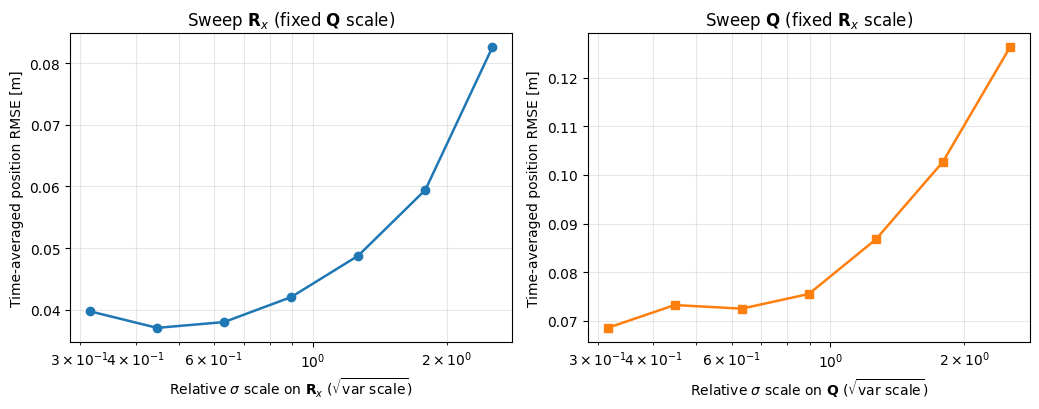

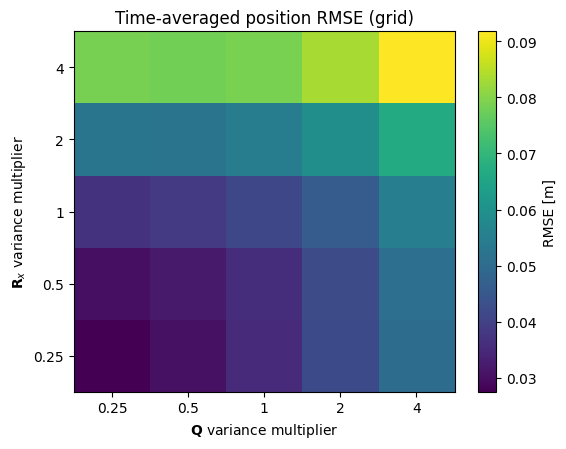

In [25]:
# 1.10 — Sensitivity playground (uses `run_full_stack` from section 1.8)

from __future__ import annotations

import copy
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np


def default_slam_cfg(seed: int | None) -> SimpleNamespace:
    """Baseline config aligned with the validated `cfg` in section 1.8."""
    return SimpleNamespace(
        seed=seed,  # -> 你需要修改这里的（函数入参默认种子）
        N_landmarks=4,  # -> 你需要修改这里的（路标个数）
        lm_bounds_lo=np.array([0.0, 0.0]),  # -> 你需要修改这里的（路标采样下界）
        lm_bounds_hi=np.array([5.0, 5.0]),  # -> 你需要修改这里的（路标采样上界）
        lm_min_dist=0.5,  # -> 你需要修改这里的（路标距原点最小距离）
        dt=0.10,  # -> 你需要修改这里的（仿真步长，与 1.8 一致时可不动）
        T=120,  # -> 你需要修改这里的（仿真步数）
        u_nom=np.array([0.50, 0.15]),  # -> 你需要修改这里的（标称控制 v,w）
        R_x=np.diag([0.01**2, 0.01**2, (1.0 * np.pi / 180.0) ** 2]),  # -> 你需要修改这里的（基准过程噪声 R_x，与 1.8 对齐）
        Q=np.diag([0.02**2, (2.0 * np.pi / 180.0) ** 2]),  # -> 你需要修改这里的（基准量测噪声 Q，与 1.8 对齐）
        bias_v=1.07,  # -> 你需要修改这里的（真值速度偏置，与 1.8 对齐）
        bias_w=0.96,  # -> 你需要修改这里的（真值角速度偏置，与 1.8 对齐）
        R_exec=np.diag([0.02**2, (2.0 * np.pi / 180.0) ** 2]),  # -> 你需要修改这里的（真值执行控制噪声，与 1.8 对齐）
        Sigma0_pose=np.diag([1e-4, 1e-4, (1 * np.pi / 180.0) ** 2]),  # -> 你需要修改这里的（初始位姿协方差）
        Sigma0_lm_var=1e6,  # -> 你需要修改这里的（初始路标方差）
        ellipse_steps=np.arange(0, 121, 10),  # -> 你需要修改这里的（仅影响 1.8 轨迹图椭圆步；本单元不用可忽略）
    )


def scale_Rx_Q(
    base: SimpleNamespace,
    *,
    r_pose_var_scale: float,
    q_meas_var_scale: float,
    seed: int | None,
) -> SimpleNamespace:
    """Scale variance matrices (multiply entries of `R_x` and `Q` by given factors)."""
    cfg = copy.copy(base)
    cfg.seed = seed
    cfg.R_x = np.asarray(base.R_x, dtype=float) * float(r_pose_var_scale)
    cfg.Q = np.asarray(base.Q, dtype=float) * float(q_meas_var_scale)
    return cfg


def trajectory_position_rmse(MU_hist: np.ndarray, GT_hist: np.ndarray) -> float:
    err = MU_hist[:, :2] - GT_hist[:, :2]
    return float(np.mean(np.sqrt(np.sum(err * err, axis=1))))


def mean_mc_rmse(
    base: SimpleNamespace,
    *,
    r_pose_var_scale: float,
    q_meas_var_scale: float,
    n_mc: int,
    seed0: int,
) -> float:
    vals: list[float] = []
    for i in range(int(n_mc)):
        sd: int | None = None if base.seed is None else int(seed0 + i)
        cfg = scale_Rx_Q(
            base,
            r_pose_var_scale=r_pose_var_scale,
            q_meas_var_scale=q_meas_var_scale,
            seed=sd,
        )
        MU_hist, GT_hist, _, _ = run_full_stack(cfg)
        vals.append(trajectory_position_rmse(MU_hist, GT_hist))
    return float(np.mean(vals))


# ---------------------------------------------------------------------------
# <mark> Student knobs — edit sweeps, fixed multipliers, and MC count </mark>
# ---------------------------------------------------------------------------
BASE = default_slam_cfg(seed=947)  # -> 你需要修改这里的（基准 cfg 的随机种子；或与 1.8 对齐时改 `default_slam_cfg` 内各字段）

# Multiplicative factors on *entire* covariance matrices (variance scale).
R_VAR_SWEEP = np.array([0.1, 0.2, 0.4, 0.8, 1.6, 3.2, 6.4], dtype=float)  # -> 你需要修改这里的（过程噪声 R_x 方差扫描倍率）
Q_VAR_SWEEP = np.array([0.1, 0.2, 0.4, 0.8, 1.6, 3.2, 6.4], dtype=float)  # -> 你需要修改这里的（量测噪声 Q 方差扫描倍率）

Q_FIXED_FOR_R_SWEEP = 0.5  # -> 你需要修改这里的（扫 R_x 时固定 Q 的方差倍率）
R_FIXED_FOR_Q_SWEEP = 5.0  # -> 你需要修改这里的（扫 Q 时固定 R_x 的方差倍率）

N_MC = 8  # -> 你需要修改这里的（蒙特卡洛重复次数，越大曲线越平滑、越慢）
MC_SEED0 = 3724  # -> 你需要修改这里的（蒙特卡洛起始随机种子）

rmse_vs_R = [
    mean_mc_rmse(
        BASE,
        r_pose_var_scale=float(r),
        q_meas_var_scale=float(Q_FIXED_FOR_R_SWEEP),
        n_mc=N_MC,
        seed0=MC_SEED0,
    )
    for r in R_VAR_SWEEP
]
rmse_vs_Q = [
    mean_mc_rmse(
        BASE,
        r_pose_var_scale=float(R_FIXED_FOR_Q_SWEEP),
        q_meas_var_scale=float(q),
        n_mc=N_MC,
        seed0=MC_SEED0,
    )
    for q in Q_VAR_SWEEP
]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))  # -> 你需要修改这里的（图像尺寸，可选）
ax0, ax1 = axes

ax0.semilogx(np.sqrt(R_VAR_SWEEP), rmse_vs_R, "o-", lw=1.8)
ax0.set_xlabel(r"Relative $\sigma$ scale on $\mathbf{R}_x$ ($\sqrt{\mathrm{var\ scale}}$)")
ax0.set_ylabel("Time-averaged position RMSE [m]")
ax0.set_title(r"Sweep $\mathbf{R}_x$ (fixed $\mathbf{Q}$ scale)")
ax0.grid(True, which="both", alpha=0.3)

ax1.semilogx(np.sqrt(Q_VAR_SWEEP), rmse_vs_Q, "s-", color="tab:orange", lw=1.8)
ax1.set_xlabel(r"Relative $\sigma$ scale on $\mathbf{Q}$ ($\sqrt{\mathrm{var\ scale}}$)")
ax1.set_ylabel("Time-averaged position RMSE [m]")
ax1.set_title(r"Sweep $\mathbf{Q}$ (fixed $\mathbf{R}_x$ scale)")
ax1.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: 2D grid — set False for a faster first pass
DO_HEATMAP = True  # -> 你需要修改这里的（True/False：是否绘制二维热力图）
if DO_HEATMAP:
    Rg = np.array([0.25, 0.5, 1.0, 2.0, 4.0], dtype=float)  # -> 你需要修改这里的（热力图 R_x 方差倍率网格）
    Qg = np.array([0.25, 0.5, 1.0, 2.0, 4.0], dtype=float)  # -> 你需要修改这里的（热力图 Q 方差倍率网格）
    Z = np.zeros((Rg.size, Qg.size), dtype=float)
    for i, r in enumerate(Rg):
        for j, q in enumerate(Qg):
            Z[i, j] = mean_mc_rmse(
                BASE,
                r_pose_var_scale=float(r),
                q_meas_var_scale=float(q),
                n_mc=max(2, N_MC // 2 + 1),
                seed0=MC_SEED0 + 500,
            )
    fig2, ax2 = plt.subplots(figsize=(5.8, 4.6))            # -> 你需要修改这里的（热力图尺寸，可选）
    im = ax2.imshow(Z, origin="lower", aspect="auto", cmap="viridis")
    ax2.set_xticks(np.arange(len(Qg)))
    ax2.set_xticklabels([f"{x:g}" for x in Qg])
    ax2.set_yticks(np.arange(len(Rg)))
    ax2.set_yticklabels([f"{x:g}" for x in Rg])
    ax2.set_xlabel(r"$\mathbf{Q}$ variance multiplier")
    ax2.set_ylabel(r"$\mathbf{R}_x$ variance multiplier")
    ax2.set_title("Time-averaged position RMSE (grid)")
    plt.colorbar(im, ax=ax2, label="RMSE [m]")
    plt.tight_layout()
    plt.show()


### 保持 R_x 角度项不变并调大平移分量，

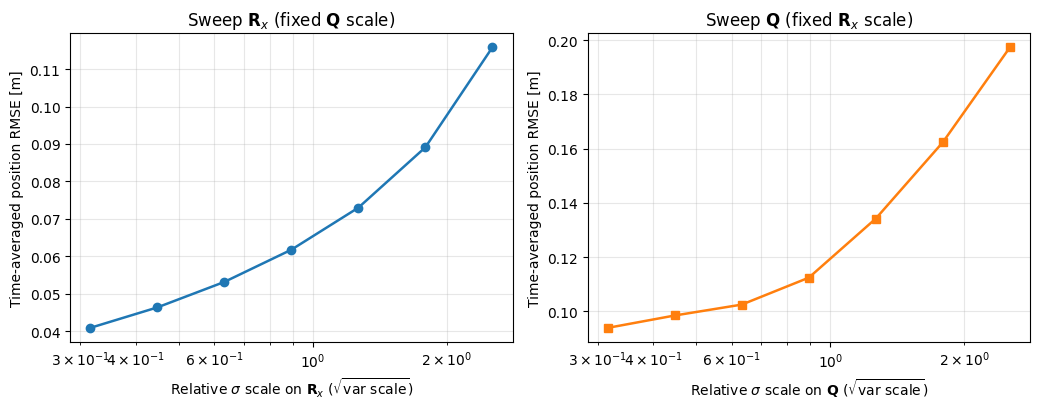

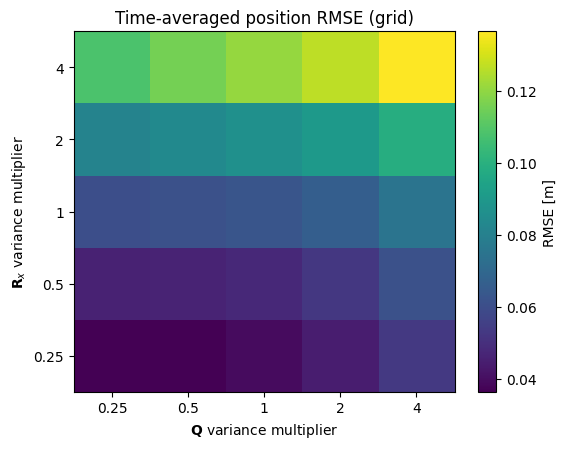

In [27]:
# 1.10 — Sensitivity playground (uses `run_full_stack` from section 1.8)

from __future__ import annotations

import copy
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np


def default_slam_cfg(seed: int | None) -> SimpleNamespace:
    """Baseline config aligned with the validated `cfg` in section 1.8."""
    return SimpleNamespace(
        seed=seed,  # -> 你需要修改这里的（函数入参默认种子）
        N_landmarks=4,  # -> 你需要修改这里的（路标个数）
        lm_bounds_lo=np.array([0.0, 0.0]),  # -> 你需要修改这里的（路标采样下界）
        lm_bounds_hi=np.array([5.0, 5.0]),  # -> 你需要修改这里的（路标采样上界）
        lm_min_dist=0.5,  # -> 你需要修改这里的（路标距原点最小距离）
        dt=0.10,  # -> 你需要修改这里的（仿真步长，与 1.8 一致时可不动）
        T=120,  # -> 你需要修改这里的（仿真步数）
        u_nom=np.array([0.50, 0.15]),  # -> 你需要修改这里的（标称控制 v,w）
        R_x=np.diag([0.1**2, 0.1**2, (1.0 * np.pi / 180.0) ** 2]),  # -> 你需要修改这里的（基准过程噪声 R_x，与 1.8 对齐）
        Q=np.diag([0.02**2, (2.0 * np.pi / 180.0) ** 2]),  # -> 你需要修改这里的（基准量测噪声 Q，与 1.8 对齐）
        bias_v=1.07,  # -> 你需要修改这里的（真值速度偏置，与 1.8 对齐）
        bias_w=0.96,  # -> 你需要修改这里的（真值角速度偏置，与 1.8 对齐）
        R_exec=np.diag([0.02**2, (2.0 * np.pi / 180.0) ** 2]),  # -> 你需要修改这里的（真值执行控制噪声，与 1.8 对齐）
        Sigma0_pose=np.diag([1e-4, 1e-4, (1 * np.pi / 180.0) ** 2]),  # -> 你需要修改这里的（初始位姿协方差）
        Sigma0_lm_var=1e6,  # -> 你需要修改这里的（初始路标方差）
        ellipse_steps=np.arange(0, 121, 10),  # -> 你需要修改这里的（仅影响 1.8 轨迹图椭圆步；本单元不用可忽略）
    )


def scale_Rx_Q(
    base: SimpleNamespace,
    *,
    r_pose_var_scale: float,
    q_meas_var_scale: float,
    seed: int | None,
) -> SimpleNamespace:
    """Scale variance matrices (multiply entries of `R_x` and `Q` by given factors)."""
    cfg = copy.copy(base)
    cfg.seed = seed
    cfg.R_x = np.asarray(base.R_x, dtype=float) * float(r_pose_var_scale)
    cfg.Q = np.asarray(base.Q, dtype=float) * float(q_meas_var_scale)
    return cfg


def trajectory_position_rmse(MU_hist: np.ndarray, GT_hist: np.ndarray) -> float:
    err = MU_hist[:, :2] - GT_hist[:, :2]
    return float(np.mean(np.sqrt(np.sum(err * err, axis=1))))


def mean_mc_rmse(
    base: SimpleNamespace,
    *,
    r_pose_var_scale: float,
    q_meas_var_scale: float,
    n_mc: int,
    seed0: int,
) -> float:
    vals: list[float] = []
    for i in range(int(n_mc)):
        sd: int | None = None if base.seed is None else int(seed0 + i)
        cfg = scale_Rx_Q(
            base,
            r_pose_var_scale=r_pose_var_scale,
            q_meas_var_scale=q_meas_var_scale,
            seed=sd,
        )
        MU_hist, GT_hist, _, _ = run_full_stack(cfg)
        vals.append(trajectory_position_rmse(MU_hist, GT_hist))
    return float(np.mean(vals))


# ---------------------------------------------------------------------------
# <mark> Student knobs — edit sweeps, fixed multipliers, and MC count </mark>
# ---------------------------------------------------------------------------
BASE = default_slam_cfg(seed=947)  # -> 你需要修改这里的（基准 cfg 的随机种子；或与 1.8 对齐时改 `default_slam_cfg` 内各字段）

# Multiplicative factors on *entire* covariance matrices (variance scale).
R_VAR_SWEEP = np.array([0.1, 0.2, 0.4, 0.8, 1.6, 3.2, 6.4], dtype=float)  # -> 你需要修改这里的（过程噪声 R_x 方差扫描倍率）
Q_VAR_SWEEP = np.array([0.1, 0.2, 0.4, 0.8, 1.6, 3.2, 6.4], dtype=float)  # -> 你需要修改这里的（量测噪声 Q 方差扫描倍率）

Q_FIXED_FOR_R_SWEEP = 0.5  # -> 你需要修改这里的（扫 R_x 时固定 Q 的方差倍率）
R_FIXED_FOR_Q_SWEEP = 5.0  # -> 你需要修改这里的（扫 Q 时固定 R_x 的方差倍率）

N_MC = 8  # -> 你需要修改这里的（蒙特卡洛重复次数，越大曲线越平滑、越慢）
MC_SEED0 = 3724  # -> 你需要修改这里的（蒙特卡洛起始随机种子）

rmse_vs_R = [
    mean_mc_rmse(
        BASE,
        r_pose_var_scale=float(r),
        q_meas_var_scale=float(Q_FIXED_FOR_R_SWEEP),
        n_mc=N_MC,
        seed0=MC_SEED0,
    )
    for r in R_VAR_SWEEP
]
rmse_vs_Q = [
    mean_mc_rmse(
        BASE,
        r_pose_var_scale=float(R_FIXED_FOR_Q_SWEEP),
        q_meas_var_scale=float(q),
        n_mc=N_MC,
        seed0=MC_SEED0,
    )
    for q in Q_VAR_SWEEP
]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))  # -> 你需要修改这里的（图像尺寸，可选）
ax0, ax1 = axes

ax0.semilogx(np.sqrt(R_VAR_SWEEP), rmse_vs_R, "o-", lw=1.8)
ax0.set_xlabel(r"Relative $\sigma$ scale on $\mathbf{R}_x$ ($\sqrt{\mathrm{var\ scale}}$)")
ax0.set_ylabel("Time-averaged position RMSE [m]")
ax0.set_title(r"Sweep $\mathbf{R}_x$ (fixed $\mathbf{Q}$ scale)")
ax0.grid(True, which="both", alpha=0.3)

ax1.semilogx(np.sqrt(Q_VAR_SWEEP), rmse_vs_Q, "s-", color="tab:orange", lw=1.8)
ax1.set_xlabel(r"Relative $\sigma$ scale on $\mathbf{Q}$ ($\sqrt{\mathrm{var\ scale}}$)")
ax1.set_ylabel("Time-averaged position RMSE [m]")
ax1.set_title(r"Sweep $\mathbf{Q}$ (fixed $\mathbf{R}_x$ scale)")
ax1.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: 2D grid — set False for a faster first pass
DO_HEATMAP = True  # -> 你需要修改这里的（True/False：是否绘制二维热力图）
if DO_HEATMAP:
    Rg = np.array([0.25, 0.5, 1.0, 2.0, 4.0], dtype=float)  # -> 你需要修改这里的（热力图 R_x 方差倍率网格）
    Qg = np.array([0.25, 0.5, 1.0, 2.0, 4.0], dtype=float)  # -> 你需要修改这里的（热力图 Q 方差倍率网格）
    Z = np.zeros((Rg.size, Qg.size), dtype=float)
    for i, r in enumerate(Rg):
        for j, q in enumerate(Qg):
            Z[i, j] = mean_mc_rmse(
                BASE,
                r_pose_var_scale=float(r),
                q_meas_var_scale=float(q),
                n_mc=max(2, N_MC // 2 + 1),
                seed0=MC_SEED0 + 500,
            )
    fig2, ax2 = plt.subplots(figsize=(5.8, 4.6))            # -> 你需要修改这里的（热力图尺寸，可选）
    im = ax2.imshow(Z, origin="lower", aspect="auto", cmap="viridis")
    ax2.set_xticks(np.arange(len(Qg)))
    ax2.set_xticklabels([f"{x:g}" for x in Qg])
    ax2.set_yticks(np.arange(len(Rg)))
    ax2.set_yticklabels([f"{x:g}" for x in Rg])
    ax2.set_xlabel(r"$\mathbf{Q}$ variance multiplier")
    ax2.set_ylabel(r"$\mathbf{R}_x$ variance multiplier")
    ax2.set_title("Time-averaged position RMSE (grid)")
    plt.colorbar(im, ax=ax2, label="RMSE [m]")
    plt.tight_layout()
    plt.show()


### 默认示例：

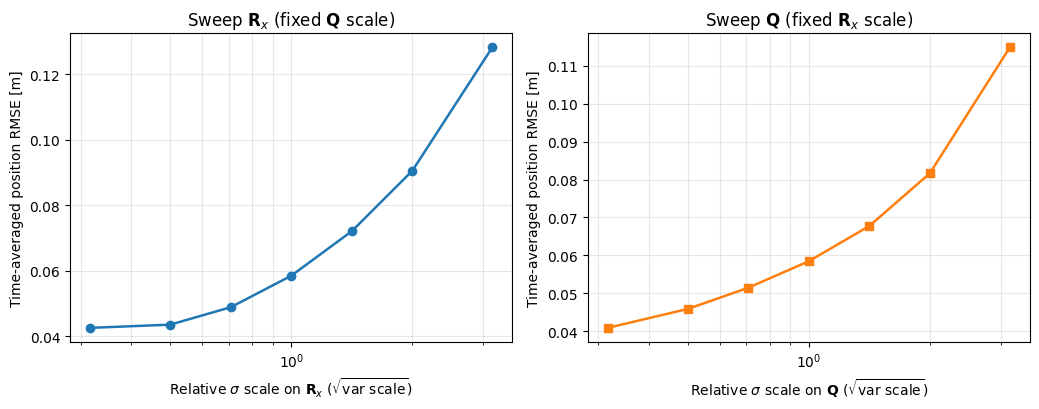

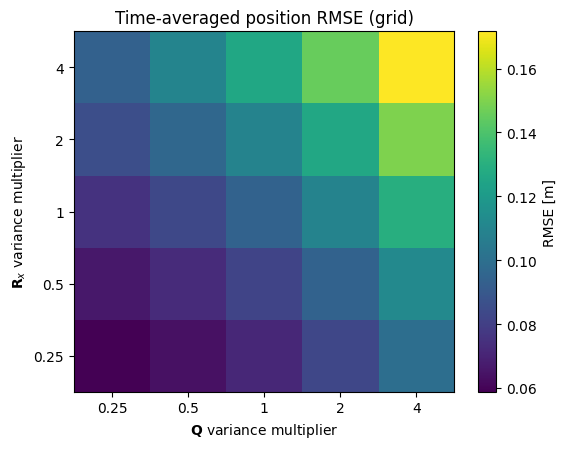

In [21]:
# 1.10 — Sensitivity playground (uses `run_full_stack` from section 1.8)

from __future__ import annotations

import copy
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np


def default_slam_cfg(seed: int | None) -> SimpleNamespace:
    """Baseline config aligned with the validated `cfg` in section 1.8."""
    return SimpleNamespace(
        seed=seed,  # -> 你需要修改这里的（函数入参默认种子）
        N_landmarks=4,  # -> 你需要修改这里的（路标个数）
        lm_bounds_lo=np.array([0.0, 0.0]),  # -> 你需要修改这里的（路标采样下界）
        lm_bounds_hi=np.array([5.0, 5.0]),  # -> 你需要修改这里的（路标采样上界）
        lm_min_dist=0.5,  # -> 你需要修改这里的（路标距原点最小距离）
        dt=0.10,  # -> 你需要修改这里的（仿真步长，与 1.8 一致时可不动）
        T=120,  # -> 你需要修改这里的（仿真步数）
        u_nom=np.array([0.50, 0.15]),  # -> 你需要修改这里的（标称控制 v,w）
        R_x=np.diag([0.01**2, 0.01**2, (1.0 * np.pi / 180.0) ** 2]),  # -> 你需要修改这里的（基准过程噪声 R_x，与 1.8 对齐）
        Q=np.diag([0.02**2, (2.0 * np.pi / 180.0) ** 2]),  # -> 你需要修改这里的（基准量测噪声 Q，与 1.8 对齐）
        bias_v=1.07,  # -> 你需要修改这里的（真值速度偏置，与 1.8 对齐）
        bias_w=0.96,  # -> 你需要修改这里的（真值角速度偏置，与 1.8 对齐）
        R_exec=np.diag([0.02**2, (2.0 * np.pi / 180.0) ** 2]),  # -> 你需要修改这里的（真值执行控制噪声，与 1.8 对齐）
        Sigma0_pose=np.diag([1e-4, 1e-4, (1 * np.pi / 180.0) ** 2]),  # -> 你需要修改这里的（初始位姿协方差）
        Sigma0_lm_var=1e6,  # -> 你需要修改这里的（初始路标方差）
        ellipse_steps=np.arange(0, 121, 10),  # -> 你需要修改这里的（仅影响 1.8 轨迹图椭圆步；本单元不用可忽略）
    )


def scale_Rx_Q(
    base: SimpleNamespace,
    *,
    r_pose_var_scale: float,
    q_meas_var_scale: float,
    seed: int | None,
) -> SimpleNamespace:
    """Scale variance matrices (multiply entries of `R_x` and `Q` by given factors)."""
    cfg = copy.copy(base)
    cfg.seed = seed
    cfg.R_x = np.asarray(base.R_x, dtype=float) * float(r_pose_var_scale)
    cfg.Q = np.asarray(base.Q, dtype=float) * float(q_meas_var_scale)
    return cfg


def trajectory_position_rmse(MU_hist: np.ndarray, GT_hist: np.ndarray) -> float:
    err = MU_hist[:, :2] - GT_hist[:, :2]
    return float(np.mean(np.sqrt(np.sum(err * err, axis=1))))


def mean_mc_rmse(
    base: SimpleNamespace,
    *,
    r_pose_var_scale: float,
    q_meas_var_scale: float,
    n_mc: int,
    seed0: int,
) -> float:
    vals: list[float] = []
    for i in range(int(n_mc)):
        sd: int | None = None if base.seed is None else int(seed0 + i)
        cfg = scale_Rx_Q(
            base,
            r_pose_var_scale=r_pose_var_scale,
            q_meas_var_scale=q_meas_var_scale,
            seed=sd,
        )
        MU_hist, GT_hist, _, _ = run_full_stack(cfg)
        vals.append(trajectory_position_rmse(MU_hist, GT_hist))
    return float(np.mean(vals))


# ---------------------------------------------------------------------------
# <mark> Student knobs — edit sweeps, fixed multipliers, and MC count </mark>
# ---------------------------------------------------------------------------
BASE = default_slam_cfg(seed=0)  # -> 你需要修改这里的（基准 cfg 的随机种子；或与 1.8 对齐时改 `default_slam_cfg` 内各字段）

# Multiplicative factors on *entire* covariance matrices (variance scale).
R_VAR_SWEEP = np.array([0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 10.0], dtype=float)  # -> 你需要修改这里的（过程噪声 R_x 方差扫描倍率）
Q_VAR_SWEEP = np.array([0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 10.0], dtype=float)  # -> 你需要修改这里的（量测噪声 Q 方差扫描倍率）

Q_FIXED_FOR_R_SWEEP = 1.0  # -> 你需要修改这里的（扫 R_x 时固定 Q 的方差倍率）
R_FIXED_FOR_Q_SWEEP = 1.0  # -> 你需要修改这里的（扫 Q 时固定 R_x 的方差倍率）

N_MC = 3  # -> 你需要修改这里的（蒙特卡洛重复次数，越大曲线越平滑、越慢）
MC_SEED0 = 100  # -> 你需要修改这里的（蒙特卡洛起始随机种子）

rmse_vs_R = [
    mean_mc_rmse(
        BASE,
        r_pose_var_scale=float(r),
        q_meas_var_scale=float(Q_FIXED_FOR_R_SWEEP),
        n_mc=N_MC,
        seed0=MC_SEED0,
    )
    for r in R_VAR_SWEEP
]
rmse_vs_Q = [
    mean_mc_rmse(
        BASE,
        r_pose_var_scale=float(R_FIXED_FOR_Q_SWEEP),
        q_meas_var_scale=float(q),
        n_mc=N_MC,
        seed0=MC_SEED0,
    )
    for q in Q_VAR_SWEEP
]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))  # -> 你需要修改这里的（图像尺寸，可选）
ax0, ax1 = axes

ax0.semilogx(np.sqrt(R_VAR_SWEEP), rmse_vs_R, "o-", lw=1.8)
ax0.set_xlabel(r"Relative $\sigma$ scale on $\mathbf{R}_x$ ($\sqrt{\mathrm{var\ scale}}$)")
ax0.set_ylabel("Time-averaged position RMSE [m]")
ax0.set_title(r"Sweep $\mathbf{R}_x$ (fixed $\mathbf{Q}$ scale)")
ax0.grid(True, which="both", alpha=0.3)

ax1.semilogx(np.sqrt(Q_VAR_SWEEP), rmse_vs_Q, "s-", color="tab:orange", lw=1.8)
ax1.set_xlabel(r"Relative $\sigma$ scale on $\mathbf{Q}$ ($\sqrt{\mathrm{var\ scale}}$)")
ax1.set_ylabel("Time-averaged position RMSE [m]")
ax1.set_title(r"Sweep $\mathbf{Q}$ (fixed $\mathbf{R}_x$ scale)")
ax1.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: 2D grid — set False for a faster first pass
DO_HEATMAP = True  # -> 你需要修改这里的（True/False：是否绘制二维热力图）
if DO_HEATMAP:
    Rg = np.array([0.25, 0.5, 1.0, 2.0, 4.0], dtype=float)  # -> 你需要修改这里的（热力图 R_x 方差倍率网格）
    Qg = np.array([0.25, 0.5, 1.0, 2.0, 4.0], dtype=float)  # -> 你需要修改这里的（热力图 Q 方差倍率网格）
    Z = np.zeros((Rg.size, Qg.size), dtype=float)
    for i, r in enumerate(Rg):
        for j, q in enumerate(Qg):
            Z[i, j] = mean_mc_rmse(
                BASE,
                r_pose_var_scale=float(r),
                q_meas_var_scale=float(q),
                n_mc=max(2, N_MC // 2 + 1),
                seed0=MC_SEED0 + 500,
            )
    fig2, ax2 = plt.subplots(figsize=(5.8, 4.6))            # -> 你需要修改这里的（热力图尺寸，可选）
    im = ax2.imshow(Z, origin="lower", aspect="auto", cmap="viridis")
    ax2.set_xticks(np.arange(len(Qg)))
    ax2.set_xticklabels([f"{x:g}" for x in Qg])
    ax2.set_yticks(np.arange(len(Rg)))
    ax2.set_yticklabels([f"{x:g}" for x in Rg])
    ax2.set_xlabel(r"$\mathbf{Q}$ variance multiplier")
    ax2.set_ylabel(r"$\mathbf{R}_x$ variance multiplier")
    ax2.set_title("Time-averaged position RMSE (grid)")
    plt.colorbar(im, ax=ax2, label="RMSE [m]")
    plt.tight_layout()
    plt.show()


-----

## 🧾 Part 2 — <span style="color:#a4d4a3">**Particle filter for SLAM**</span>（50 分）


<span style="color:#00703c">**问题:**</span>

卡尔曼滤波及其变体只建模 <span style="color:#ffa500">**高斯分布**</span>。

<span style="color:#00703c">**目标:**</span>

能够处理 <span style="color:#ffa500">**任意分布**</span>。

粒子滤波 的核心思想是：
- 用  <span style="color:#ffa500">**多个样本（**</span> (粒子) 来表示对位姿的信念。
- 某个区域内的样本越多， <span style="color:#ffa500">**概率越高**</span>.
- 为样本分配 <span style="color:#ffa500">**权重**</span>；权重越大 ⇒ 概率越高。

### 2.1 什么是 “粒子”

<span style="color:#ffa500">**粒子**</span> 是一组带权重的样本：

$$
\mathcal{X} = \left\{\left\langle x_t^{[j]},\,w_t^{[j]}\right\rangle\right\}_{j=1,\ldots,J}
$$

其中：

- $x_t^{[j]}$ 是一个 <span style="color:#ffa500">**状态假设**</span>
- $w_t^{[j]}$ 是  <span style="color:#ffa500">**重要性权重**</span>.


这些样本表示  <span style="color:#ffa500">**后验**</span>:

$$
p(x)\ \approx\ \sum_{j=1}^{J} w^{[j]}\,\delta_{x^{[j]}}(x)
$$

其中 $\delta_x$ 是 <span style="color:#ffa500">**Dirac**</span> 分布。

运行下方代码来撒粒子

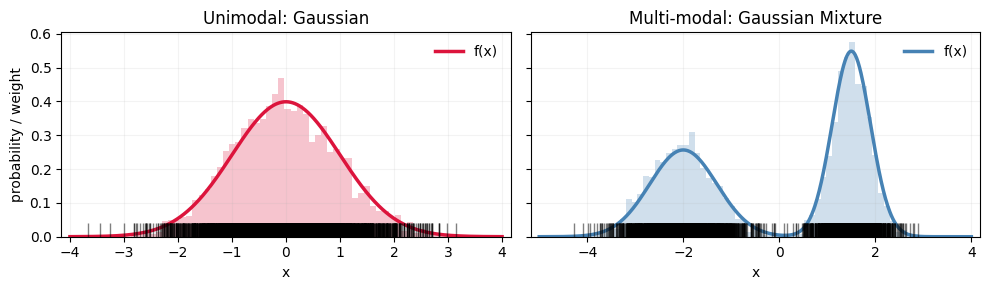

In [16]:
# --- Particles for Approximation: unimodal vs. multimodal ---
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

# ---- target pdfs ----
def normal_pdf(x, mu=0.0, sigma=1.0):
    c = 1.0 / (np.sqrt(2*np.pi) * sigma)
    return c * np.exp(-0.5 * ((x - mu)/sigma)**2)

def mix2_pdf(x, w=0.45, mu1=-2.0, s1=0.7, mu2=1.5, s2=0.4):
    return w*normal_pdf(x, mu1, s1) + (1-w)*normal_pdf(x, mu2, s2)

def sample_mix2(n, w=0.45, mu1=-2.0, s1=0.7, mu2=1.5, s2=0.4, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    sel = rng.uniform(size=n) < w
    x = np.empty(n)
    x[sel]  = rng.normal(mu1, s1, sel.sum())
    x[~sel] = rng.normal(mu2, s2, (~sel).sum())
    return x

# ---- draw samples ----
J = 3000  # number of particles
samples_uni = rng.normal(0.0, 1.0, J)
samples_mix = sample_mix2(J, rng=rng)

# ---- plotting ----
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)

# Ranges for pdf curves
x1 = np.linspace(-4, 4, 600)
x2 = np.linspace(-5, 4, 600)

# Left: unimodal Gaussian
ax = axes[0]
ax.plot(x1, normal_pdf(x1, 0.0, 1.0), lw=2.5, color='crimson', label='f(x)')
ax.hist(samples_uni, bins=60, density=True, histtype='stepfilled', alpha=0.25, color='crimson')
ax.plot(samples_uni, np.full_like(samples_uni, ax.get_ylim()[0]), '|', ms=20, color='black', alpha=0.5)  # rug
ax.set_xlabel('x')
ax.set_ylabel('probability / weight')
ax.set_title('Unimodal: Gaussian')
ax.legend(loc='upper right', frameon=False)

# Right: bimodal mixture
ax = axes[1]
ax.plot(x2, mix2_pdf(x2), lw=2.5, color='steelblue', label='f(x)')
ax.hist(samples_mix, bins=60, density=True, histtype='stepfilled', alpha=0.25, color='steelblue')
ax.plot(samples_mix, np.full_like(samples_mix, ax.get_ylim()[0]), '|', ms=20, color='black', alpha=0.5)  # rug
ax.set_xlabel('x')
ax.set_title('Multi-modal: Gaussian Mixture')
ax.legend(loc='upper right', frameon=False)

for ax in axes:
    ax.margins(x=0.02)
    ax.grid(alpha=0.15)

fig.tight_layout()

上方的左侧图刻画了一个单峰高斯分布，右侧图刻画了一个多峰混合分布。横轴上的 rug 刻度线 表示粒子的位置。

我们可以发现可以用大量样本（粒子）去逼近目标分布。某个区域内粒子越密，该区域被估计的概率就越高。

### 2.2 如何获取这些 “粒子” ？———— 重要性采样

我们可以用另一个  <span style="color:#ffa500">**提议（proposal）**</span> 分布 $g(x)$ 来生成来自 <span style="color:#ffa500">**目标分布**</span> $f(x)$ 的样本。用权重 $w(x)$ 来补偿两者之间的差异：

$$
w(x)\ \propto\ \frac{f(x)}{g(x)}
$$


在下面的例子中，我们比较 <span style="color:#ffa500">**两种提议分布**</span>  用重要性采样来逼近一个双峰的目标密度 $f(x)$。

我们采样 $x^{[j]} \sim g(x)$ 并赋予权重  $w^{[j]} \propto \frac{f(x^{[j]})}{g(x^{[j]})}$.

True mean ≈ 0.470 | IS mean (good) ≈ 0.498 | IS mean (bad) ≈ 0.307


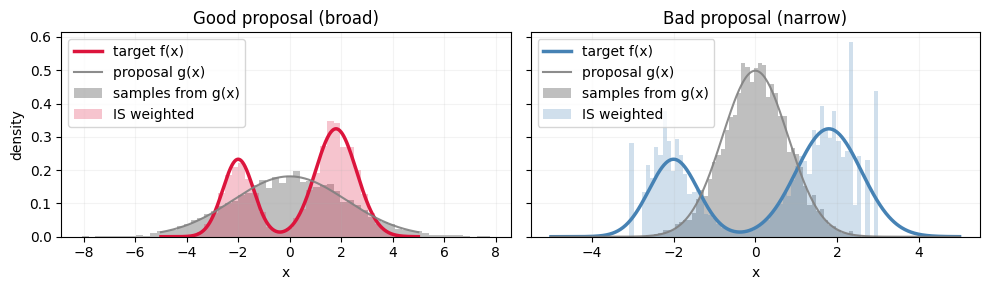

In [17]:
# --- Importance Sampling demo: recovering a target pdf from proposal samples ---
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2)

# ---- utilities ----
def normal_pdf(x, mu, sigma):
    return (1.0 / (np.sqrt(2*np.pi)*sigma)) * np.exp(-0.5*((x-mu)/sigma)**2)

# Target: bimodal mixture (normalized)
def target_pdf(x):
    return 0.35*normal_pdf(x, -2.0, 0.6) + 0.65*normal_pdf(x, 1.8, 0.8)

# Proposals (both positive everywhere)
def g_good_pdf(x):  # broad, covers both modes well
    return normal_pdf(x, 0.0, 2.2)

def g_bad_pdf(x):   # too narrow, poor tail/mode coverage
    return normal_pdf(x, 0.0, 0.8)

def sample_g_good(n, rng):
    return rng.normal(0.0, 2.2, n)

def sample_g_bad(n, rng):
    return rng.normal(0.0, 0.8, n)

# ---- sampling ----
J = 5000
x_good = sample_g_good(J, rng)
x_bad  = sample_g_bad(J, rng)

# Unnormalized importance weights (proportional to f/g)
w_good = target_pdf(x_good) / g_good_pdf(x_good)
w_bad  = target_pdf(x_bad)  / g_bad_pdf(x_bad)

# Normalize for estimators (sum to 1)
w_good /= np.sum(w_good)
w_bad  /= np.sum(w_bad)

# Check a simple expectation: mean of x under f(x)
true_mean = 0.35*(-2.0) + 0.65*(1.8)  # mixture mean
is_mean_good = np.sum(w_good * x_good)
is_mean_bad  = np.sum(w_bad  * x_bad)
print(f"True mean ≈ {true_mean:.3f} | IS mean (good) ≈ {is_mean_good:.3f} | IS mean (bad) ≈ {is_mean_bad:.3f}")

# ---- plotting ----
xs = np.linspace(-5, 5, 800)
fxs = target_pdf(xs)

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)

# Left: GOOD proposal
ax = axes[0]
ax.plot(xs, fxs, lw=2.5, color='crimson', label='target f(x)')
ax.plot(xs, g_good_pdf(xs), lw=1.5, color='gray', alpha=0.9, label='proposal g(x)')
# Unweighted histogram shows proposal density (for comparison)
ax.hist(x_good, bins=60, density=True,  alpha=0.5, color='gray', label='samples from g(x)')
# Weighted histogram approximates f(x)
ax.hist(x_good, bins=60, density=True, weights=w_good, alpha=0.25, color='crimson', label='IS weighted')
ax.set_title('Good proposal (broad)'); ax.set_xlabel('x'); ax.set_ylabel('density')
ax.legend(loc='upper left'); ax.grid(alpha=0.15)

# Right: BAD proposal
ax = axes[1]
ax.plot(xs, fxs, lw=2.5, color='steelblue', label='target f(x)')
ax.plot(xs, g_bad_pdf(xs), lw=1.5, color='gray', alpha=0.9, label='proposal g(x)')
ax.hist(x_bad, bins=60, density=True, alpha=0.5, color='gray', label='samples from g(x)')
ax.hist(x_bad, bins=60, density=True, weights=w_bad, alpha=0.25, color='steelblue', label='IS weighted')
ax.set_title('Bad proposal (narrow)'); ax.set_xlabel('x')
ax.legend(loc='upper left'); ax.grid(alpha=0.15)
fig.tight_layout()

我们观察上面两幅图，可以发现与目标匹配良好的提议分布会产生加权直方图，使其紧密贴合目标函数 $f$；糟糕的提议分布会导致少数权重占主导，从而得到噪声很大的近似。

### 2.3 粒子滤波

粒子滤波是递归贝叶斯滤波器 的一种实现。更具体地说，它是一种非参数方法，不维护闭式分布。

如前所述，核心思想是用样本来建模任意任意分布。因此贝叶斯滤波器的两个步骤是：

1. 预测步： 从提议分布中抽取样本（使用 运动模型 进行采样）。
2. 校正步： 利用 观测 计算校正量（或权重）。

使用的样本越多，估计通常就越好！


> <tt> <span style="color:#4D96FF">def</span> **<span style="color:#6BCB77">Particle_Filter</span>($\color{#ffa500}\mathcal{X}_{t-1}, \color{#ffa500}u_t, \color{#ffa500}z_t$):**    
>>
>> <span style="color:#FF2DD1">1.</span> $\bar{\mathcal{X}}_t = \mathcal{X}_t = \emptyset \quad$ <span style="color:#948979"># 初始化</span>
>>
>> <span style="color:#FF2DD1">2.</span> <span style="color:#e74c3c">for</span> $j=1$ <span style="color:#ffa500">to</span> $J$ <span style="color:#e74c3c">do</span>: $\quad$ <span style="color:#948979"># 对所有的粒子进行迭代</span>    
>>>
>>> <span style="color:#FF2DD1">3.</span> $x_t^{[j]} \sim \pi(x_t) \quad$ <span style="color:#948979"># 从 proposal distribution 中采样</span>
>>>
>>> <span style="color:#FF2DD1">4.</span> $w_t^{[j]} = \frac{p(x_t^{[j]})}{\pi(x_t^{[j]})} \quad$ <span style="color:#948979"># 计算修正权重 </span>
>>>
>>> <span style="color:#FF2DD1">5.</span> $\bar{\mathcal{X}}_t = \bar{\mathcal{X}}_t + \langle x_t^{[j]}, w_t^{[j]}\rangle \quad$ <span style="color:#948979">#添加至预测集</span>
>>
>><span style="color:#FF2DD1">6.</span> <span style="color:#e74c3c">endfor</span>
>>
>> <span style="color:#FF2DD1">7.</span> <span style="color:#e74c3c">for</span> $j=1$ <span style="color:#ffa500">to</span> $J$ <span style="color:#e74c3c">do</span>: $\quad$<span style="color:#948979"># 重采样</span>  
>>>
>>><span style="color:#FF2DD1">8.</span> <span style="color:#ffa500">draw</span> $i \in 1, \ldots, J$ <span style="color:#ffa500">with probability</span> $\propto w_t^{[i]}$
>>>
>>><span style="color:#FF2DD1">9.</span> <span style="color:#ffa500">add</span> $x_t^{[i]}$ <span style="color:#ffa500">to</span> $\mathcal{X}_t$
>>>
>><span style="color:#FF2DD1">10.</span> <span style="color:#e74c3c">endfor</span>    
>>
>><span style="color:#FF2DD1">11.</span> <span style="color:#e74c3c">return</span> $\mathcal{X}_t$

其中，重采样（resample）通过重新分配我们有限的粒子预算来更新粒子集合。它让低权重（不太可能）的样本被淘汰，并复制高权重的样本，从而使粒子集合在每一步都更好地刻画信念。

- 剪枝：去掉低权重（不太可能）的粒子 —— 让弱假设 消亡。
- 复制：复制高权重（较可能）的粒子 —— 形成 更强 的假设。
- 把计算资源集中在状态空间中 高概率区域。
- 适者生存；一种避免大量样本覆盖不太可能状态的技巧。

重采样方法

1. 轮盘赌重采样：
- 构造 归一化 权重的累积和（CDF）。
- 独立抽取 $J$ 个均匀随机数 $u_j \sim \mathcal{U}(0,1)$。
- 对每个 $u_j$，找到第一个满足 CDF $\ge u_j$ 的区间（例如用 二分查找），并复制对应粒子。
- 复杂度：配合二分查找为 $O(J \log J)$。
- 简单，但 方差较大；少数高权重粒子可能被多次选中。

2. 随机通用采样（SUS）
- 构造 归一化 权重的 CDF。
- 抽取单个随机偏移 $r \sim \mathcal{U}(0, 1/J)$。
- 放置 $J$ 个等间距指针于 $r,, r+\tfrac{1}{J},, r+\tfrac{2}{J},\dots, r+\tfrac{J-1}{J}$。
- 对每个指针，选择第一个满足 CDF $\ge$ 指针的区间并复制对应粒子。
- 复杂度：对 CDF 一次扫描为 $O(J)$。
- 低方差；分配更接近期望计数，相比轮盘赌能减轻样本贫乏（sample impoverishment）。

### 2.4 蒙特卡洛定位

对于机器人而言，我们考虑一个定位问题，即地图（例如占据栅格地图）已知，我们如何知道我们在地图中的哪个位置？

MCL 是 粒子滤波 的一个 专门化实例，面向固定地图下的位姿估计。

- 每个粒子是一个位姿假设。
- 提议分布 是 运动模型：

  $$
  x_t^{[j]} \sim p(x_t \mid x_{t-1}, u_t)
  $$

- 通过 观测模型（已知地图 $m$）进行 校正
  $$
  w_t^{[j]} = \frac{\text{target}}{\text{proposal}} \propto p(z_t \mid x_t, m)
  $$

若回顾 Particle_Filter 算法，则 MCL 与之相同，只需把第 3. 行与第 4. 行替换为：

>>>  <tt><span style="color:#FF2DD1">3.</span></tt> $x_t^{[j]} \sim p(x_t \mid x_{t-1}^{[j]}, u_t) \quad$ <span style="color:#948979"># 从 proposal distribution 采样</span>
>>>
>>>  <tt><span style="color:#FF2DD1">4.</span></tt> $w_t^{[j]} = p(z_t \mid x_t^{[j]}) \quad$ <span style="color:#948979"># 计算校正权重 </span>

下面我们实现一个可交互在固定占据栅格地图上实现 MCL，传感器模型采用似然场（预先计算距离变换）。
其中，粒子会吸附到空闲像素上，显示的位姿估计从随机空闲位姿开始。

In [18]:
# ===================================================
# Fast & Stable MCL (Pixel-Quantized Particles)
# GT (left) | MCL (right; red particles)
# Colab / Jupyter: headless pygame + ipywidgets (see Run cell).
# ===================================================

import io
import os
import sys

try:
    import google.colab  # type: ignore[import-not-found]
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False
if _IN_COLAB or os.environ.get("HELLO_SLAM_HEADLESS") == "1":
    os.environ.setdefault("SDL_VIDEODRIVER", "dummy")

import numpy as np
import pygame
from typing import Optional

# --- Helpers ---
def wrap_angle(a: float) -> float:
    return (a + np.pi) % (2*np.pi) - np.pi

def i2(p):
    """(x,y) -> (int,int)"""
    return (int(p[0]), int(p[1]))

def circ_mean_thetas(th: np.ndarray, w: np.ndarray) -> float:
    """Compute the circular mean of angles.
    Args:
        th: (N,) array of angles in radians
        w:  (N,) array of weights (not necessarily normalized)
    Returns:
        single angle in radians
    """
    s = np.sum(w * np.sin(th)); c = np.sum(w * np.cos(th))
    return np.arctan2(s, c)

def blend_pose(prev: Optional[np.ndarray], cur: np.ndarray, alpha: float = 0.5) -> np.ndarray:
    """EMA smoothing of pose; angle blended on the circle.
    Args:
        prev: (3,) previous pose (x,y,theta) or None
        cur:  (3,) current pose (x,y,theta)
        alpha: blending factor (0 <= alpha <= 1)
    Returns:
        (3,) blended pose (x,y,theta)
    """
    if prev is None: return cur.copy()
    x = (1-alpha)*prev[0] + alpha*cur[0]
    y = (1-alpha)*prev[1] + alpha*cur[1]
    dth = wrap_angle(cur[2] - prev[2])
    th  = wrap_angle(prev[2] + alpha*dth)
    return np.array([x,y,th], dtype=np.float32)


def ensure_floor_plan_image(cfg: "Config") -> str:
    """Return an absolute path to a floor-plan PNG: prefer local files, else download cfg.floor_plan_url."""
    from urllib.error import HTTPError, URLError
    from urllib.request import Request, urlopen

    candidates: list = []
    if getattr(cfg, "floor_img_path", None):
        candidates.append(str(cfg.floor_img_path))
    for rel in ("../figures/floor_plan.png", "figures/floor_plan.png", "floor_plan.png"):
        if rel not in candidates:
            candidates.append(rel)

    for p in candidates:
        if p and os.path.isfile(p):
            return os.path.abspath(p)

    url = getattr(cfg, "floor_plan_url", None)
    if not url:
        raise FileNotFoundError(
            "No floor plan PNG found. Options: (1) Upload PNG to Colab (/content) and set "
            "Config.floor_img_path, e.g. '/content/floor_plan.png'. "
            "(2) Set Config.floor_plan_url to a direct HTTPS link to the PNG."
        )

    cache = getattr(cfg, "floor_plan_cache_path", None) or os.path.join(
        os.getcwd(), "floor_plan_downloaded.png"
    )
    cache = os.path.abspath(cache)
    parent = os.path.dirname(cache)
    if parent:
        os.makedirs(parent, exist_ok=True)

    req = Request(url, headers={"User-Agent": "Mozilla/5.0 (compatible; MCL-demo/1.0)"})
    try:
        with urlopen(req, timeout=120) as resp:
            data = resp.read()
    except (URLError, HTTPError) as e:
        raise RuntimeError(f"Failed to download floor_plan_url: {e}") from e

    with open(cache, "wb") as f:
        f.write(data)
    return cache


# -------------------- Config --------------------
class Config:
    panel_w, panel_h = 500, 400
    window_size = (panel_w*2, panel_h)

    traj_max = 300

    # Floor plan: local first (see ensure_floor_plan_image); else download floor_plan_url (Colab-friendly).
    floor_img_path = "floor_plan.png"
    floor_plan_url = "https://i.ibb.co/BKT1C2Lt/floor-plan.png"
    floor_plan_cache_path = None  # None -> <cwd>/floor_plan_downloaded.png

    # LiDAR
    num_beams   = 180
    fov_deg     = 360
    scan_ms     = 120
    ray_stride  = 2
    max_range_px = 250
    beam_subsample_step = 2

    # ipywidgets Play interval (ms): beam animation + PNG refresh in Jupyter/Colab
    widget_play_interval_ms = 50
    viz_fan_rays = 72
    beam_sweep_hz_desktop = 10.0
    beam_sweep_hz_notebook = 0.65

    # Motion (odometry-style command dr1, dt, dr2)
    trans_step = 12.0
    rot_step   = np.deg2rad(12.0)

    # Motion noise covariance (diagonal) for standard additive model
    R_x = np.diag([1.0**2, 1.0**2, (2.0 * np.pi / 180.0)**2]).astype(np.float32)

    # Likelihood-field model
    sigma_hit = 8.0           # [px] std of endpoint distance to nearest wall
    use_only_hit_beams = True # ignore max-range beams (poorly informative)

    # Particles / resampling (note: particles are pixels)
    Np = 1000
    resample_neff_ratio = 0.5
    random_injection_frac = 0.01

    # Estimation
    top_k_frac = 0.8          # estimate from top-K by weight (robust)
    smooth_alpha = 0.5        # EMA smoothing on pose estimate

    # Drawing
    draw_particles = True
    particle_color = (220, 40, 40)  # red like the screenshot
    draw_top_k_particles = None     # None = draw all

    seed = 0

# --- Panel ---
class Panel:
    def __init__(self, screen, rect): self.screen, self.rect = screen, rect
    @property
    def ox(self): return self.rect[0]
    def clear(self, color):
        pygame.draw.rect(self.screen, color, self.rect)
        pygame.draw.rect(self.screen, (200,200,200), self.rect, 2)
    def blit(self, surf, at=(0,0)):
        x,y,_,_ = self.rect; self.screen.blit(surf, (x+at[0], y+at[1]))
    def polygon(self, color, pts):
        x,y,_,_ = self.rect; P = [(x+int(px), y+int(py)) for (px,py) in pts]
        pygame.draw.polygon(self.screen, color, P)
    def circle(self, color, p, r):
        x,y,_,_ = self.rect; pygame.draw.circle(self.screen, color, (x+int(p[0]), y+int(p[1])), r)
    def text(self, font, s, color, pos):
        x,y,_,_ = self.rect; self.screen.blit(font.render(s, True, color), (x+pos[0], y+pos[1]))

# --- Map + distance field ---
class Map2D:
    def __init__(self, cfg: Config, floor_img_path: Optional[str] = None) -> None:
        self.cfg = cfg
        path = floor_img_path if floor_img_path is not None else ensure_floor_plan_image(cfg)
        self.surface = pygame.transform.smoothscale(
            pygame.image.load(path), (cfg.panel_w, cfg.panel_h)
        )
        arr = pygame.surfarray.array3d(self.surface)  # (W,H,3) (x,y,RGB)
        self.wall_mask = np.all(arr < 128, axis=2).astype(np.bool_)  # True=wall
        self.free_mask = ~self.wall_mask
        # Precompute list of free pixel coordinates (x,y) for fast sampling
        free_xy = np.where(self.free_mask)          # tuple of (x_idx, y_idx)
        self.free_coords = np.stack(free_xy, axis=1).astype(np.int32)  # (Nfree,2)
        self.dist_field = self._build_distance_field()

    def _build_distance_field(self):
        W,H = self.wall_mask.shape
        try:
            import scipy.ndimage as ndi
            return ndi.distance_transform_edt(self.free_mask).astype(np.float32)
        except Exception:
            # chamfer fallback
            inf = 1e9
            df = np.full((W, H), inf, dtype=np.float32)
            df[self.wall_mask] = 0.0
            # forward pass
            for x in range(W):
                xm1 = x-1
                for y in range(H):
                    d = df[x,y]
                    if xm1 >= 0: d = min(d, df[xm1,y] + 1.0)
                    ym1 = y-1
                    if ym1 >= 0: d = min(d, df[x,ym1] + 1.0)
                    if (xm1 >= 0) and (ym1 >= 0): d = min(d, df[xm1,ym1] + np.sqrt(2.0))
                    xp1 = x+1
                    if (xp1 < W) and (ym1 >= 0): d = min(d, df[xp1,ym1] + np.sqrt(2.0))
                    df[x,y] = d
            # backward pass
            for x in range(W-1,-1,-1):
                xp1 = x+1
                for y in range(H-1,-1,-1):
                    d = df[x,y]
                    if xp1 < W: d = min(d, df[xp1,y] + 1.0)
                    yp1 = y+1
                    if yp1 < H: d = min(d, df[x,yp1] + 1.0)
                    if (xp1 < W) and (yp1 < H): d = min(d, df[xp1,yp1] + np.sqrt(2.0))
                    xm1 = x-1
                    if (xm1 >= 0) and (yp1 < H): d = min(d, df[xm1,yp1] + np.sqrt(2.0))
                    df[x,y] = d
            return df

    def cast_beam_fast(self, pos_xy: tuple, angle: float, max_r: float):
        """Cast a ray from pos_xy at given angle (radians) up to max_r pixels.
        Args:
            pos_xy: (x,y) start position in pixels (float)
            angle: angle in radians
            max_r: maximum range in pixels
        Returns:
            (x_hit, y_hit): hit position in pixels (int) or None if no hit
            r: distance to hit in pixels (int) or max_r if no hit
        """
        W, H = self.wall_mask.shape
        x0, y0 = float(pos_xy[0]), float(pos_xy[1])
        c, s = np.cos(angle), np.sin(angle)
        for d in range(0, int(max_r), self.cfg.ray_stride):
            x = int(x0 + d*c); y = int(y0 + d*s)
            if not (0 <= x < W and 0 <= y < H):
                return None, d
            if self.wall_mask[x, y]:
                return (x, y), d
        return None, int(max_r)

    def random_free_xy(self, rng: np.random.Generator):
        """Return a random FREE pixel (x,y) as float (center of pixel).
        Args:
            rng: np.random.Generator instance
        Returns:
            (x,y): coordinates of a FREE pixel (float)
        """
        idx = rng.integers(0, self.free_coords.shape[0])
        x, y = self.free_coords[idx]
        return float(x), float(y)

    def sample_free_pixels(self, rng: np.random.Generator, n: int, replace: bool = True):
        """Sample n FREE pixels (x,y) as integers.
        Args:
            rng: np.random.Generator instance
            n: number of pixels to sample
            replace: whether to sample with replacement
        Returns:
            (n,2) array of FREE pixel coordinates (int32)
        """
        total = self.free_coords.shape[0]
        replace = (n > total) or replace
        idx = rng.choice(total, size=n, replace=replace)
        return self.free_coords[idx].copy()  # (n,2) int32

    def nearest_free_to(self, x_c: float, y_c: float):
        """Nearest FREE pixel to a given (x_c,y_c).
        Args:
            x_c: x coordinate (float)
            y_c: y coordinate (float)
        Returns:
            (x,y): coordinates of the nearest FREE pixel (float)
        """
        dx = self.free_coords[:,0] - x_c
        dy = self.free_coords[:,1] - y_c
        j = np.argmin(dx*dx + dy*dy)
        fx, fy = self.free_coords[j]
        return float(fx), float(fy)

# --- LiDAR (GT scan) ---
class Lidar:
    def __init__(self, cfg: Config, world_map: Map2D):
        self.cfg = cfg; self.map = world_map

    def scan(self, pose_xyth: tuple, rng: np.random.Generator) -> tuple:
        """Simulate a LiDAR scan from given pose (x,y,theta).
        Args:
            pose_xyth: (x,y,theta) pose in world coordinates (float)
            rng: np.random.Generator instance
        Returns:
            (Z_r, Z_phi): range and bearing measurements (numpy arrays)
        """
        x, y, th = map(float, pose_xyth)
        fov = np.deg2rad(self.cfg.fov_deg)
        bearings = np.linspace(-fov/2, fov/2, self.cfg.num_beams, endpoint=False)
        Z_r = np.empty(self.cfg.num_beams, dtype=np.float32)
        Z_phi = np.empty_like(Z_r)
        for i, rel in enumerate(bearings):
            a = wrap_angle(th + rel)
            _, dist = self.map.cast_beam_fast((x, y), a, self.cfg.max_range_px)
            Z_r[i] = dist + rng.normal(0.0, 1.5)  # mild sensor noise
            Z_phi[i] = rel
        return Z_r, Z_phi

# --- bilinear sampler ---
def bilinear_sample(field: np.ndarray, xs: np.ndarray, ys: np.ndarray) -> np.ndarray:
    """Bilinear sampling of a 2D field at given (x,y) coordinates.
    Args:
        field: 2D array to sample from
        xs: x coordinates (float)
        ys: y coordinates (float)
    Returns:
        2D array of sampled values (float)
    """
    W, H = field.shape
    xs = np.clip(xs, 0.0, W-1.001); ys = np.clip(ys, 0.0, H-1.001)
    x0 = np.floor(xs).astype(np.int32); y0 = np.floor(ys).astype(np.int32)
    x1 = np.minimum(x0+1, W-1); y1 = np.minimum(y0+1, H-1)
    wx = xs - x0; wy = ys - y0
    v00 = field[x0, y0]; v10 = field[x1, y0]
    v01 = field[x0, y1]; v11 = field[x1, y1]
    return (v00*(1-wx)*(1-wy) + v10*wx*(1-wy) + v01*(1-wx)*wy + v11*wx*wy)

# --- Particle Filter (MCL, particles at pixels) ---
class ParticleFilterMCL:
    def __init__(self, cfg: Config, world_map: Map2D, rng: np.random.Generator) -> None:
        self.cfg, self.map, self.rng = cfg, world_map, rng
        self.N = cfg.Np
        self.x = np.zeros((self.N, 3), dtype=np.float32)   # (x,y,theta)
        self.w = np.ones(self.N, dtype=np.float32) / self.N
        self.global_initialize()

    def _snap_to_pixel(self):
        """Round positions to nearest pixel center (integer coordinates)."""
        self.x[:,0] = np.rint(self.x[:,0])
        self.x[:,1] = np.rint(self.x[:,1])

    def _repair_outside_or_wall(self, mask_bad: np.ndarray):
        """Reseed bad particles to random FREE pixels (keeps orientation).
        Args:
            mask_bad: (N,) boolean array, True for bad particles
        """
        if not np.any(mask_bad): return
        repl = self.map.sample_free_pixels(self.rng, int(mask_bad.sum()), replace=True)
        self.x[mask_bad, 0] = repl[:,0]
        self.x[mask_bad, 1] = repl[:,1]

    def global_initialize(self):
        # Sample FREE pixels (without replacement if possible)
        coords = self.map.sample_free_pixels(self.rng, self.N, replace=False)
        thetas = self.rng.uniform(-np.pi, np.pi, size=self.N).astype(np.float32)
        self.x[:,0] = coords[:,0]; self.x[:,1] = coords[:,1]; self.x[:,2] = thetas
        self.w.fill(1.0/self.N)

    def predict(self, u: np.ndarray) -> None:
        """
        Standard motion model.
        Args:
            u: (dr1, dt, dr2) odometry command (float)
        """
        dr1, dt, dr2 = float(u[0]), float(u[1]), float(u[2])
        th = self.x[:, 2]

        # Odometry motion (deterministic part)
        th_mid = th + dr1
        ct = np.cos(th_mid); st = np.sin(th_mid)
        x_new = self.x[:, 0] + dt * ct
        y_new = self.x[:, 1] + dt * st
        th_new = th + dr1 + dr2

        # Sample additive noise from N(0, R_x)
        std = np.sqrt(np.diag(self.cfg.R_x))
        noise = self.rng.normal(0.0, std, size=(self.N, 3))

        # Rotate translational noise from body to world
        ex_b, ey_b, eth = noise[:,0], noise[:,1], noise[:,2]
        ex_w = ct * ex_b - st * ey_b
        ey_w = st * ex_b + ct * ey_b

        # Add noise to motion
        self.x[:, 0] = x_new + ex_w
        self.x[:, 1] = y_new + ey_w
        self.x[:, 2] = np.array([wrap_angle(tn + e) for tn, e in zip(th_new, eth)], dtype=np.float32)

        # Snap and repair
        self._snap_to_pixel()
        xi = self.x[:,0].astype(np.int32); yi = self.x[:,1].astype(np.int32)
        W,H = self.map.wall_mask.shape
        inside = (xi >= 0) & (xi < W) & (yi >= 0) & (yi < H)
        ok = np.zeros(self.N, dtype=bool)
        ok[inside] = self.map.free_mask[xi[inside], yi[inside]]
        bad = ~ok
        self._repair_outside_or_wall(bad)

    def update(self, Z_r: np.ndarray, Z_phi: np.ndarray):
        """Measurement update (correction) step with LiDAR scan Z = (Z_r, Z_phi).
        Args:
            Z_r: (M,) array of range measurements (float)
            Z_phi: (M,) array of bearing measurements (float)
        """
        if Z_r.size == 0: return
        step = max(1, int(self.cfg.beam_subsample_step))
        r = Z_r[::step].astype(np.float32)
        phi = Z_phi[::step].astype(np.float32)
        if self.cfg.use_only_hit_beams:
            mask = r < (self.cfg.max_range_px - 1.5*self.cfg.ray_stride)
            if np.any(mask):
                r = r[mask]; phi = phi[mask]
            else:
                return
        th = self.x[:, 2][:, None]                 # (N,1)
        ang = th + phi[None, :]                    # (N,M)
        ex = self.x[:, 0][:, None] + r[None, :]*np.cos(ang)
        ey = self.x[:, 1][:, None] + r[None, :]*np.sin(ang)

        d = bilinear_sample(self.map.dist_field, ex, ey)  # (N,M)
        inv_2sig2 = 1.0 / (2.0 * self.cfg.sigma_hit * self.cfg.sigma_hit)
        log_lik = -np.mean(d*d, axis=1) * inv_2sig2

        logw = np.log(self.w + 1e-12) + log_lik
        m = np.max(logw)
        w = np.exp(logw - m); w /= (np.sum(w) + 1e-12)
        self.w = w.astype(np.float32)

    def neff(self):
        """Effective sample size."""
        return 1.0 / (np.sum(self.w**2) + 1e-12)

    def resample_if_needed(self):
        if self.neff() < self.cfg.resample_neff_ratio * self.N:
            self.systematic_resample()
            self.inject_random(int(self.cfg.random_injection_frac * self.N))

    def systematic_resample(self):
        N = self.N
        positions = (self.rng.random() + np.arange(N)) / N
        indexes = np.zeros(N, dtype=np.int32)
        c = self.w[0]; i = 0
        for j in range(N):
            u = positions[j]
            while u > c and i < N-1:
                i += 1; c += self.w[i]
            indexes[j] = i
        self.x = self.x[indexes].copy()
        self.w.fill(1.0/N)
        # Ensure we remain snapped after resampling
        self._snap_to_pixel()

    def inject_random(self, k: int):
        """Inject k random particles (replacing worst k by weight).
        Args:
            k: number of particles to inject
        """
        if k <= 0: return
        repl = self.map.sample_free_pixels(self.rng, k, replace=True)
        idx = self.rng.choice(self.N, size=k, replace=False)
        self.x[idx, 0] = repl[:,0]; self.x[idx, 1] = repl[:,1]
        self.x[idx, 2] = self.rng.uniform(-np.pi, np.pi, size=k).astype(np.float32)

    def estimate_topk(self, frac: float=0.2) -> np.ndarray:
        """Estimate pose from top-K particles by weight.
        Args:
            frac: fraction of particles to use (0 < frac <= 1)
        Returns:
            (3,) estimated pose (x,y,theta)
        """
        k = max(1, int(frac * self.N))
        idx = np.argsort(self.w)[-k:]
        w = self.w[idx]; w = w / (np.sum(w) + 1e-12)
        x = float(np.sum(w * self.x[idx,0]))
        y = float(np.sum(w * self.x[idx,1]))
        th = float(circ_mean_thetas(self.x[idx,2], w))
        return np.array([x,y,th], dtype=np.float32)

# --- App ---
class App:
    def __init__(self, cfg: Config, use_display: bool = True) -> None:
        pygame.init()
        self.cfg = cfg
        self.use_display = use_display
        if use_display:
            self.screen = pygame.display.set_mode(cfg.window_size)
            pygame.display.set_caption("GT (left) | MCL (right)")
        else:
            if os.environ.get("SDL_VIDEODRIVER") == "dummy":
                self.screen = pygame.display.set_mode(cfg.window_size)
            else:
                self.screen = pygame.Surface(cfg.window_size)

        self.clock = pygame.time.Clock()
        self.font = pygame.font.SysFont(None, 18)
        self.rng = np.random.default_rng(cfg.seed)

        self.left = Panel(self.screen, (0, 0, cfg.panel_w, cfg.panel_h))
        self.right = Panel(self.screen, (cfg.panel_w, 0, cfg.panel_w, cfg.panel_h))

        self.map = Map2D(cfg)
        self.lidar = Lidar(cfg, self.map)

        cx, cy = cfg.panel_w // 2, cfg.panel_h // 2
        gx, gy = self.map.nearest_free_to(cx, cy)
        self.gt_pose = np.array([gx, gy, 0.0], dtype=np.float32)
        self.gt_traj = [self.gt_pose.copy()]

        self.pf = ParticleFilterMCL(cfg, self.map, self.rng)
        self.frozen = True
        rx, ry = self.map.random_free_xy(self.rng)
        rth = self.rng.uniform(-np.pi, np.pi)
        self.est_pose = np.array([rx, ry, rth], dtype=np.float32)

        hz = cfg.beam_sweep_hz_desktop if use_display else cfg.beam_sweep_hz_notebook
        self.beam_speed = 2 * np.pi * hz
        self.beam_angle = 0.0

        self._scan_accum_ms = 0
        self._hud_fps_notebook = 0.0

        self.SCAN_EVENT = pygame.USEREVENT + 1

        self.last_scan = (np.array([], dtype=np.float32), np.array([], dtype=np.float32))
        self.draw_particles = cfg.draw_particles

    @staticmethod
    def motion_model_odometry(u: np.ndarray, x_prev: np.ndarray) -> np.ndarray:
        """Apply odometry-style motion model to pose x_prev with command u = (dr1, dt, dr2)."""
        dr1, dt, dr2 = float(u[0]), float(u[1]), float(u[2])
        x_new = x_prev[0] + dt * np.cos(x_prev[2] + dr1)
        y_new = x_prev[1] + dt * np.sin(x_prev[2] + dr1)
        th_new = wrap_angle(float(x_prev[2] + dr1 + dr2))
        return np.array([x_new, y_new, th_new], dtype=np.float32)

    def step_motion(self, cmd: np.ndarray) -> None:
        """Apply motion model to ground truth pose and predict particle states."""
        self.frozen = False
        self.gt_pose = self.motion_model_odometry(cmd, self.gt_pose)
        self.gt_traj.append(self.gt_pose.copy())
        self.gt_traj = self.gt_traj[-self.cfg.traj_max :]
        self.pf.predict(cmd)

    def step_scan(self) -> None:
        """Perform a LiDAR scan and update the particle filter."""
        Z_r, Z_phi = self.lidar.scan(self.gt_pose, self.rng)
        self.last_scan = (Z_r, Z_phi)
        if self.frozen:
            return
        self.pf.update(Z_r, Z_phi)
        self.pf.resample_if_needed()
        est_now = self.pf.estimate_topk(self.cfg.top_k_frac)
        self.est_pose = blend_pose(self.est_pose, est_now, self.cfg.smooth_alpha)

    def _draw_gt_lidar_fan(self) -> None:
        """Draw GT-centered range rays (stable at low UI FPS)."""
        gx_f, gy_f, gth = map(float, self.gt_pose)
        ox = self.left.ox
        fov = np.deg2rad(float(self.cfg.fov_deg))
        n = max(8, int(self.cfg.viz_fan_rays))
        if abs(fov - 2.0 * np.pi) < 1e-6:
            angles = gth + np.linspace(-np.pi, np.pi, n, endpoint=False)
        else:
            angles = gth + np.linspace(-0.5 * fov, 0.5 * fov, n, endpoint=True)
        col = (210, 100, 100)
        mr = float(self.cfg.max_range_px)
        for a in angles:
            af = float(a)
            hit, _dist = self.map.cast_beam_fast(self.gt_pose[:2], af, self.cfg.max_range_px)
            if hit:
                ex_i, ey_i = int(hit[0]), int(hit[1])
            else:
                ex_i = int(gx_f + mr * np.cos(af))
                ey_i = int(gy_f + mr * np.sin(af))
            pygame.draw.line(self.screen, col, (ox + int(gx_f), int(gy_f)), (ox + ex_i, ey_i), 1)

    def draw_left(self) -> None:
        self.left.clear((30, 30, 30))
        self.left.blit(self.map.surface, (0, 0))

        if not self.use_display:
            self._draw_gt_lidar_fan()

        for i in range(1, len(self.gt_traj)):
            p0 = i2(self.gt_traj[i - 1][:2])
            p1 = i2(self.gt_traj[i][:2])
            pygame.draw.line(
                self.screen,
                (0, 150, 255),
                (self.left.ox + p0[0], p0[1]),
                (self.left.ox + p1[0], p1[1]),
                2,
            )

        gx, gy, gth = map(float, self.gt_pose)
        pts = [
            (gx + 15 * np.cos(gth), gy + 15 * np.sin(gth)),
            (gx + 10 * np.cos(gth + 2.5), gy + 10 * np.sin(gth + 2.5)),
            (gx + 10 * np.cos(gth - 2.5), gy + 10 * np.sin(gth - 2.5)),
        ]
        self.left.polygon((0, 150, 255), pts)

        gx_f, gy_f = float(self.gt_pose[0]), float(self.gt_pose[1])
        hit, _dist = self.map.cast_beam_fast(self.gt_pose[:2], float(self.beam_angle), self.cfg.max_range_px)
        if hit:
            ex, ey = int(hit[0]), int(hit[1])
        else:
            ex = int(gx_f + self.cfg.max_range_px * np.cos(self.beam_angle))
            ey = int(gy_f + self.cfg.max_range_px * np.sin(self.beam_angle))
        pygame.draw.line(
            self.screen,
            (255, 220, 100),
            (self.left.ox + int(gx_f), int(gy_f)),
            (self.left.ox + ex, ey),
            2,
        )

    def draw_right(self) -> None:
        self.right.clear((230, 230, 230))
        self.right.blit(self.map.surface, (0, 0))
        if self.draw_particles:
            if self.cfg.draw_top_k_particles is None:
                idx_to_draw = np.arange(self.pf.N)
            else:
                idx_to_draw = np.argsort(self.pf.w)[-self.cfg.draw_top_k_particles :]
            for i in idx_to_draw:
                x, y, _ = self.pf.x[i]
                self.right.circle(self.cfg.particle_color, (x, y), 1)
        if self.est_pose is not None:
            ex, ey, eth = map(float, self.est_pose)
            self.right.circle((0, 180, 120), (ex, ey), 5)
            hx = ex + 14 * np.cos(eth)
            hy = ey + 14 * np.sin(eth)
            pygame.draw.line(
                self.screen,
                (0, 180, 120),
                (self.right.ox + int(ex), int(ey)),
                (self.right.ox + int(hx), int(hy)),
                2,
            )
        fps = self.clock.get_fps() if self.use_display else self._hud_fps_notebook
        neff = self.pf.neff()
        step = self.cfg.beam_subsample_step
        hud = (
            f"FPS:{fps:4.1f} | N:{self.cfg.Np} | Neff:{neff:5.1f} "
            f"| Beams:{self.cfg.num_beams}/{step} | sigma_hit={self.cfg.sigma_hit:.1f}px "
            f"| TopK:{int(self.cfg.top_k_frac * self.cfg.Np)}"
        )
        self.right.text(self.font, hud, (10, 10, 10), (10, 0))

    def screen_png_bytes(self) -> bytes:
        buf = io.BytesIO()
        pygame.image.save(self.screen, buf, "PNG")
        buf.seek(0)
        return buf.read()

    def tick_notebook_frame(self, dt_ms: int) -> None:
        dt = dt_ms / 1000.0
        self.beam_angle = (self.beam_angle + self.beam_speed * dt) % (2 * np.pi)
        self._scan_accum_ms += dt_ms
        while self._scan_accum_ms >= self.cfg.scan_ms:
            self._scan_accum_ms -= self.cfg.scan_ms
            self.step_scan()
        if dt > 0:
            inst = 1.0 / dt
            b = 0.92
            self._hud_fps_notebook = b * self._hud_fps_notebook + (1.0 - b) * inst
        self.draw_left()
        self.draw_right()

    def run_ipywidgets(self):
        import ipywidgets as widgets
        from IPython.display import display as ipy_display

        if self.use_display:
            raise RuntimeError("run_ipywidgets() requires App(cfg, use_display=False).")

        w_img, _ = self.cfg.window_size
        img_w = widgets.Image(format="png", layout=widgets.Layout(width=f"{w_img}px"))

        def push_frame() -> None:
            img_w.value = self.screen_png_bytes()

        play = widgets.Play(
            value=0,
            min=0,
            max=10**9,
            step=1,
            interval=int(self.cfg.widget_play_interval_ms),
            description="Play",
        )

        def on_play_step(_change) -> None:
            self.tick_notebook_frame(int(self.cfg.widget_play_interval_ms))
            push_frame()

        play.observe(on_play_step, names="value")

        def motion(cmd: np.ndarray) -> None:
            self.step_motion(cmd)
            self.tick_notebook_frame(0)
            push_frame()

        btn_up = widgets.Button(description="Up (forward)")
        btn_left = widgets.Button(description="Left (rotate)")
        btn_right = widgets.Button(description="Right (rotate)")
        btn_g = widgets.Button(description="Global reset (G)")
        btn_k = widgets.Button(description="Kidnap GT (K)")
        btn_p = widgets.Button(description="Toggle particles (P)")
        btn_bm = widgets.Button(description="Beam step -")
        btn_bp = widgets.Button(description="Beam step +")

        btn_up.on_click(lambda _b: motion(np.array([0.0, self.cfg.trans_step, 0.0], dtype=np.float32)))
        btn_left.on_click(lambda _b: motion(np.array([-self.cfg.rot_step, 0.0, 0.0], dtype=np.float32)))
        btn_right.on_click(lambda _b: motion(np.array([self.cfg.rot_step, 0.0, 0.0], dtype=np.float32)))

        def on_g(_b) -> None:
            self.pf.global_initialize()
            self.frozen = True
            rx, ry = self.map.random_free_xy(self.rng)
            rth = self.rng.uniform(-np.pi, np.pi)
            self.est_pose = np.array([rx, ry, rth], dtype=np.float32)
            self.tick_notebook_frame(0)
            push_frame()

        def on_k(_b) -> None:
            cx, cy = self.cfg.panel_w // 2, self.cfg.panel_h // 2
            gx, gy = self.map.nearest_free_to(cx, cy)
            self.gt_pose = np.array([gx, gy, self.rng.uniform(-np.pi, np.pi)], dtype=np.float32)
            self.gt_traj.clear()
            self.est_pose = None
            self.tick_notebook_frame(0)
            push_frame()

        def on_p(_b) -> None:
            self.draw_particles = not self.draw_particles
            self.tick_notebook_frame(0)
            push_frame()

        def on_bm(_b) -> None:
            self.cfg.beam_subsample_step = max(1, self.cfg.beam_subsample_step - 1)
            self.tick_notebook_frame(0)
            push_frame()

        def on_bp(_b) -> None:
            self.cfg.beam_subsample_step = min(12, self.cfg.beam_subsample_step + 1)
            self.tick_notebook_frame(0)
            push_frame()

        btn_g.on_click(on_g)
        btn_k.on_click(on_k)
        btn_p.on_click(on_p)
        btn_bm.on_click(on_bm)
        btn_bp.on_click(on_bp)

        controls = widgets.VBox(
            [
                widgets.HTML(
                    "<b>Controls</b> (Colab / Jupyter). Press <b>Play</b> for scan + beam animation."
                ),
                widgets.HBox([btn_up]),
                widgets.HBox([btn_left, btn_right]),
                widgets.HBox([btn_g, btn_k]),
                widgets.HBox([btn_p, btn_bm, btn_bp]),
                play,
            ]
        )
        ui = widgets.VBox([controls, img_w])
        self.draw_left()
        self.draw_right()
        push_frame()
        ipy_display(ui)
        return ui

    def run(self) -> None:
        pygame.time.set_timer(self.SCAN_EVENT, self.cfg.scan_ms)
        running = True
        while running:
            dt = self.clock.tick(60) / 1000.0
            self.beam_angle = (self.beam_angle + self.beam_speed * dt) % (2 * np.pi)
            for ev in pygame.event.get():
                if ev.type == pygame.QUIT:
                    running = False
                elif ev.type == pygame.KEYDOWN:
                    cmd: Optional[np.ndarray] = None
                    if ev.key == pygame.K_UP:
                        cmd = np.array([0.0, self.cfg.trans_step, 0.0], dtype=np.float32)
                    elif ev.key == pygame.K_LEFT:
                        cmd = np.array([-self.cfg.rot_step, 0.0, 0.0], dtype=np.float32)
                    elif ev.key == pygame.K_RIGHT:
                        cmd = np.array([self.cfg.rot_step, 0.0, 0.0], dtype=np.float32)
                    elif ev.key == pygame.K_g:
                        self.pf.global_initialize()
                        self.frozen = True
                        rx, ry = self.map.random_free_xy(self.rng)
                        rth = self.rng.uniform(-np.pi, np.pi)
                        self.est_pose = np.array([rx, ry, rth], dtype=np.float32)
                        cmd = None
                    elif ev.key == pygame.K_k:
                        cx, cy = self.cfg.panel_w // 2, self.cfg.panel_h // 2
                        gx, gy = self.map.nearest_free_to(cx, cy)
                        self.gt_pose = np.array([gx, gy, self.rng.uniform(-np.pi, np.pi)], dtype=np.float32)
                        self.gt_traj.clear()
                        self.est_pose = None
                        cmd = None
                    elif ev.key == pygame.K_COMMA:
                        self.cfg.beam_subsample_step = max(1, self.cfg.beam_subsample_step - 1)
                        cmd = None
                    elif ev.key == pygame.K_PERIOD:
                        self.cfg.beam_subsample_step = min(12, self.cfg.beam_subsample_step + 1)
                        cmd = None
                    elif ev.key == pygame.K_p:
                        self.draw_particles = not self.draw_particles
                        cmd = None
                    else:
                        cmd = None
                    if cmd is not None:
                        self.step_motion(cmd)
                elif ev.type == self.SCAN_EVENT:
                    self.step_scan()

            self.draw_left()
            self.draw_right()
            pygame.display.flip()

        pygame.time.set_timer(self.SCAN_EVENT, 0)
        pygame.quit()


执行下面的代码块启动仿真环境，通过鼠标点击虚拟按钮，可以控制机器人移动。点击开始按钮后，你可以观测到机器人实时的粒子分布和机器人定位情况的变化。

In [19]:
cfg = Config()
App(cfg, use_display=False).run_ipywidgets()

### 动手尝试（MCL 似然场小实验）

**操作提示**：须先运行上方 **MCL 主代码** 单元，保证已定义 `Config` 与 `App`。每个实验代码格可独立运行。状态栏会显示 `sigma_hit`、束数/子采样步长等，便于对照。

| 建议记录维度（每格实验填关键词即可） |  |
| --- | --- |
| 粒子云 | 单峰收敛 / 多峰徘徊 / 快速塌缩到错误区域 |
| 绿线估计（相对左图 GT） | 滞后、平滑、是否跳变 |
| 计算流畅度 | 子采样、$N_p$ 会明显影响 |

**参考理解（可对照，不必照抄）**

- `sigma_hit` 大 → 似然“更宽”，对端点-墙距离误差不敏感，更新温和，但可能收敛慢。过小则权重尖锐，对噪声敏感，易抖动或局部最优。
- `beam_subsample_step` 大 或者 只取 hit 束 → 算得更快，但信息变少；开扬区域若关 `use_only_hit_beams`，无 hit 的束在似然场模型里信息量弱，需结合地图类型理解。
- `top_k_frac`、`smooth_alpha` **只影响读出/可视化轨迹**，不改粒子集本身；$N_p$、重采样与注入才改变滤波器行为。


#### 小实验 1：宽差阈值

端点到最近的障碍距离 $d$ 的似然宽度由 `sigma_hit` 控制：越大越“宽容”，越小越“挑剔”。粒子假设一个位姿，就会根据激光束算出每条束的落点；似然场告诉你：这个落点离最近的墙有多远，记为 $d$。`sigma_hit`  就是在说：你允许这个距离 $d$ 差多少，还算“对得上”地图。

<mark> 👉  尝试修改参数后重新运行，填写表格，感受参数变化带来的影响 </mark>

| `sigma_hit` | 你观察到的现象（收敛快慢 / 估计抖动 / 错墙黏附） | 理解（一两句） |
| --- | --- | --- |
| 4.0 |  |  |
| 8.0 |  |  |
| 16.0 |  |  |

In [20]:
cfg = Config()
cfg.sigma_hit = 4.0  # 试 4.0, 8.0, 16.0
App(cfg, use_display=False).run_ipywidgets()

#### 小实验 2：观测信息量

- **`beam_subsample_step`（跳步取束）**：激光本来扫很多条射线，这里可以**每隔 $s$ 条才用 1 条**来打分。$s$ 调大，就像**少问几句就交卷**——算得快，但**用来判断的线索也少了**。
- **`use_only_hit_beams=True`（不要“没打中”的远束）**：若某条射线**一路打出去几乎没碰墙、快打到最大量程**，在这套**“端点离墙多近”**的似然里，它的信息量往往很弱，有时还会添乱。打开它，等于**只信“真的打到墙”的束**，在**走廊、房间**这类地方通常更稳。若到了**特别空旷、很少打中墙**的地方，可改成 `False` 对比看看。

<mark> 👉  尝试修改参数后重新运行，填写表格，感受参数变化带来的影响 </mark>

**表 A：固定** `use_only_hit_beams = True`，**只改**子采样 `beam_subsample_step`

| `beam_subsample_step` | 现象（快不快、稳不稳、有没有多团粒子） | 我的理解 |
| --- | --- | --- |
| 1 |  |  |
| 2 |  |  |
| 4 |  |  |

**表 B：固定** `beam_subsample_step = 2`，**只改**是否只信打中墙的束

| `use_only_hit_beams` | 现象 | 我的理解 |
| --- | --- | --- |
| `True` |  |  |
| `False` |  |  |

In [ ]:
cfg = Config()
cfg.beam_subsample_step = 2        # 修改参数后重新运行
cfg.use_only_hit_beams = True      # 修改参数后重新运行
App(cfg, use_display=False).run_ipywidgets()

#### 小实验 3：要多少颗粒子、多久“洗牌”、洗完后要不要“掺新血”

可以把粒子滤波想成**很多人一起猜位置**：人多**覆盖面大**，但每走一步**算账也更累**（更占时间）。

- **`Np`（粒子个数）**：猜的人越多，越不容易“全员看错同一处”；但人数上去，**每步计算也更慢**。
- **`resample_neff_ratio`（多久重采样）**：粒子权重要是**太不均匀**（少数粒子几乎占全部分数），就有点像“大家抄同一个答案”，这时该**重新洗牌、按权重多复制高分粒子**。

  这里的比例可以想象成：**等“有效人数”掉到什么地步才洗牌**。**数字设高一点**＝**更常洗牌**，不容易“全班只剩一个声音”，但洗牌太勤也会**更毛躁、更随机**。

- **`random_injection_frac`（洗完后硬塞几成随机人）**：洗牌之后，**故意扔掉一小撮最不可信的粒子**，在空地上**随机放新人**。这样机器人即使被**瞬间挪到远处（绑架 / 大误差）**，还有机会**从别处重新长出一团粒子**。**掺得多**＝**更敢往外探索**，但估计**更容易飘、不那么“钉死”在局部**。

<mark> 👉  尝试修改参数后重新运行，填写表格，感受参数变化带来的影响 </mark>

**表 A：只改** `Np`，其它固定为默认：`resample_neff_ratio = 0.5`，`random_injection_frac = 0.01`

| `Np` | 现象（快不快、稳不稳、多团粒子、按 K 以后好不好恢复） | 我的理解 |
| --- | --- | --- |
| 200 |  |  |
| 1000 |  |  |
| 3000 |  |  |

**表 B：只改** `resample_neff_ratio`，其它固定：`Np = 1000`，`random_injection_frac = 0.01`

| `resample_neff_ratio` | 现象 | 我的理解 |
| --- | --- | --- |
| 0.3 |  |  |
| 0.5 |  |  |
| 0.7 |  |  |

**表 C：只改** `random_injection_frac`，其它固定：`Np = 1000`，`resample_neff_ratio = 0.5`。（重点按 **K** 测“被挪走之后能不能找回来”）

| `random_injection_frac` | 现象 | 我的理解 |
| --- | --- | --- |
| 0.0 |  |  |
| 0.01 |  |  |
| 0.05 |  |  |

In [ ]:
cfg = Config()
cfg.Np = 1000  # 修改参数后重新运行
cfg.resample_neff_ratio = 0.5 # 修改参数后重新运行
cfg.random_injection_frac = 0.01 # 修改参数后重新运行
App(cfg, use_display=False).run_ipywidgets()

----

## <span style="color:#a4d4a3">**Future of SLAM**</span>

进入 2026 年，伴随着多模态基座模型能力的再次跃升，学术界和工业界频频传出“SLAM 已死”的论调。然而颇为玩味的是，OpenAI 等头部通用人工智能企业却在此时悄然放出了大量新的 SLAM 研究员岗位。这种看似矛盾的现象，恰恰暴露出当前空间智能（Spatial Intelligence）发展的一个核心痛点，也折射出了 SLAM 这门学科正在经历的深刻范式转移。

纵观 SLAM 的发展史，它一直是一门在“妥协”与“极限”中不断进化的学科。早期，我们在算力极其受限的条件下，依靠卡尔曼滤波和粒子滤波（如 EKF-SLAM、FastSLAM），用优美的统计学方法在概率空间中寻找状态的最优解。随后，以图优化（Graph Optimization）为代表的平滑方法统治了过去十余年。以 ORB-SLAM、VINS 等为代表的经典框架，将多视图几何与稀疏线性代数发挥到了极致。客观来说，对于静态、刚体、光照良好的理想环境，纯几何层面的“定位与建图”确实可以认为是一个“已解决”的问题。这就是“SLAM 已死”论调的根源——如果你现在的研究仅仅停留在传统的特征点提取、匹配和后处理优化上，确实很难再挖掘出具有高学术价值的增量。

当前的大语言模型（LLM）和视觉-语言模型（VLM）虽然拥有庞大的世界常识和惊人的语义推理能力，但它们存在一个致命缺陷：缺乏对真实三维物理世界的严格度量感知（Metric Perception）。 基座模型可以轻易认出桌子上的杯子，甚至能用自然语言描述它的材质，但它们往往无法稳定、精确地输出这个杯子在三维空间中的连续 6 DoF 坐标；它们能生成逼真的视频，却难以在长序列中维持严格的多视角几何一致性。

OpenAI 等企业招募 SLAM 人才，绝不是为了让他们去写传统的特征描述子，而是为了构建具身智能（Embodied AI）和世界模型的基础设施。未来的机器不仅需要“听懂”和“看懂”，更要在复杂的三维物理法则下“行动”。这就要求我们将基座模型的开放语义泛化能力，与传统 SLAM 极具鲁棒性的多视角几何严密性相结合。当神经网络已经具备极强的特征提取和深度估计能力时，传统几何 SLAM 中哪些坚固的数学内核（如光束法平差、李代数上的流形优化）是不可替代的？又是哪些易碎的模块（如硬数据关联、静态环境假设）必须被学习范式彻底重写？